In [2]:
%pip install PyMySQL
from sqlalchemy import create_engine, text
import ssl

## CONEXION BBDD MYSQL ##
DB_USER = "nuclio"
DB_PASS = "nuclioTFM6"
DB_HOST = "nuclio.mysql.database.azure.com"
DB_NAME = "olist"

# Crear engine apuntando a la base 'olist'
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:3306/{DB_NAME}?charset=utf8mb4",
    pool_pre_ping=True,
    connect_args={"ssl": {"cert_reqs": ssl.CERT_NONE, "check_hostname": False}} 
)


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

# Cargar tablas (ejemplo usando SQLAlchemy engine)
customers = pd.read_sql("SELECT * FROM olist_customers_dataset", con=engine)
orders = pd.read_sql("SELECT * FROM olist_orders_dataset", con=engine)
order_items = pd.read_sql("SELECT * FROM olist_order_items_dataset", con=engine)
order_payments = pd.read_sql("SELECT * FROM olist_order_payments_dataset", con=engine)
order_reviews = pd.read_sql("SELECT * FROM olist_order_reviews_dataset", con=engine)
products = pd.read_sql("SELECT * FROM olist_products_dataset", con=engine)
product_cat = pd.read_sql("SELECT * FROM product_category_name_translation", con=engine)
sellers = pd.read_sql("SELECT * FROM olist_sellers_dataset", con=engine)
geo = pd.read_sql("SELECT * FROM olist_geolocation_dataset", con=engine)

In [4]:
# Ejemplo de chequeo genérico
for df, name in [(customers,"customers"), (orders,"orders")]:
    print(f"---- {name.upper()} ----")
    print(df.isna().sum())
    print("Duplicados:", df.duplicated().sum())
    print(df.dtypes)

---- CUSTOMERS ----
id                          0
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Duplicados: 0
id                           int64
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix    object
customer_city               object
customer_state              object
dtype: object
---- ORDERS ----
id                                  0
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Duplicados: 0
id                                int64
order_id                         object
customer_id                      object
order_status                     object
ord

In [5]:
customers = customers.drop_duplicates(subset="customer_id")
sellers= sellers.drop_duplicates(subset="seller_id")

- Integración categoría producto en inglés a tabla "products":

In [6]:
products = products.merge(
    product_cat[["product_category_name", "product_category_name_english"]],
    on="product_category_name",
    how="left"
)

In [7]:
order_reviews = pd.read_csv("/Users/nataliarobles/Desktop/CURSO PYTHON/TFM RECURSOS /data/olist_order_reviews_dataset.csv")

### PORCENTAJE PEDIDOS DEMORADOS:

In [8]:
#Filtramos solo por pedidos entregados mediante dataset "orders":
orders_entregados = orders[orders["order_status"] == "delivered"]

In [9]:
orders_entregados["order_delivered_customer_date"] = pd.to_datetime(orders_entregados["order_delivered_customer_date"])
orders_entregados["order_estimated_delivery_date"] = pd.to_datetime(orders_entregados["order_estimated_delivery_date"])

/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/3848749861.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_entregados["order_delivered_customer_date"] = pd.to_datetime(orders_entregados["order_delivered_customer_date"])
/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/3848749861.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_entregados["order_estimated_delivery_date"] = pd.to_datetime(orders_entregados["order_estimated_delivery_date"])


In [10]:
#Vamos a crear una columna llamada "pedidos_demorados" dentro del dataset "orders_entregados":
orders_entregados["pedidos_demorados"]= orders_entregados["order_delivered_customer_date"] > orders_entregados["order_estimated_delivery_date"]

/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/3289950235.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_entregados["pedidos_demorados"]= orders_entregados["order_delivered_customer_date"] > orders_entregados["order_estimated_delivery_date"]


In [11]:
# Porcentaje de pedidos demorados:
total_pedidos = len(orders_entregados)
pedidos_demorados = orders_entregados["pedidos_demorados"].sum()
porcentaje_demorados = (pedidos_demorados / total_pedidos) * 100
print(f"Porcentaje de pedidos demorados: {porcentaje_demorados:.2f}%")


Porcentaje de pedidos demorados: 8.11%


### Identificar los pedidos con demora:

In [12]:
# Solo pedidos que fueron entregados más tarde de la fecha estimada:
pedidos_demorados = orders_entregados[orders_entregados["pedidos_demorados"] == True]. reset_index(drop=True)

In [13]:
num_pedidos_demorados = orders_entregados["pedidos_demorados"].sum()
print(f"Número total de pedidos demorados: {num_pedidos_demorados}")

Número total de pedidos demorados: 7826


In [14]:
pedidos_demorados = orders_entregados[orders_entregados["pedidos_demorados"]][
    ["order_id", "customer_id", "order_delivered_customer_date", "order_estimated_delivery_date", "pedidos_demorados"]
]
pedidos_demorados.head(10)

,order_id,customer_id,order_delivered_customer_date,order_estimated_delivery_date,pedidos_demorados
20,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,2017-10-09 22:23:46,2017-09-28,True
25,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,2018-03-21 22:03:54,2018-03-12,True
35,8563039e855156e48fccee4d611a3196,5f16605299d698660e0606f7eae2d2f9,2018-03-20 00:59:25,2018-03-20,True
41,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,2017-12-28 18:59:23,2017-12-21,True
57,66e4624ae69e7dc89bd50222b59f581f,684fa6da5134b9e4dab731e00011712d,2018-04-03 13:28:46,2018-04-02,True
58,a685d016c8a26f71a0bb67821070e398,911e4c37f5cafe1604fe6767034bf1ae,2017-04-06 13:37:16,2017-03-30,True
97,6a0a8bfbbe700284feb0845d95e0867f,68451b39b1314302c08c65a29f1140fc,2017-12-28 19:43:00,2017-12-11,True
102,a5474c0071dd5d1074e12d417078bbd0,ef15b3240b2083e0487762ee2978d2b8,2018-08-03 19:28:47,2018-08-02,True
110,9d531c565e28c3e0d756192f84d8731f,d4faa220408c20e53595d2950f361f3b,2018-01-23 21:38:52,2017-12-22,True
115,8fc207e94fa91a7649c5a5dab690272a,c69f8b33e62ecb30ff78ae46d7fb9241,2018-01-20 13:42:22,2017-12-19,True


### Promedio de días que tarda Olist en entregar un pedido:

In [15]:
orders_entregados["order_purchase_timestamp"]= pd.to_datetime(orders_entregados["order_purchase_timestamp"])

#Extraer año de la compra:

orders_entregados["año"] = orders_entregados["order_purchase_timestamp"].dt.year

/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/2921004072.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_entregados["order_purchase_timestamp"]= pd.to_datetime(orders_entregados["order_purchase_timestamp"])
/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/2921004072.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_entregados["año"] = orders_entregados["order_purchase_timestamp"].dt.year


In [16]:
#Creamos la columna "días_entrega":
orders_entregados["order_purchase_timestamp"] = pd.to_datetime(orders_entregados["order_purchase_timestamp"])
orders_entregados["order_delivered_customer_date"] = pd.to_datetime(orders_entregados["order_delivered_customer_date"])


/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/3957265028.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_entregados["order_purchase_timestamp"] = pd.to_datetime(orders_entregados["order_purchase_timestamp"])
/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/3957265028.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_entregados["order_delivered_customer_date"] = pd.to_datetime(orders_entregados["order_delivered_customer_date"])


In [17]:
orders_entregados["días_entrega"] = (orders_entregados["order_delivered_customer_date"] - orders_entregados["order_purchase_timestamp"]).dt.days

/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/2354241763.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_entregados["días_entrega"] = (orders_entregados["order_delivered_customer_date"] - orders_entregados["order_purchase_timestamp"]).dt.days


In [18]:
promedio_entrega_año= orders_entregados.groupby("año")["días_entrega"].mean().reset_index()
promedio_entrega_año.rename(columns={"días_entrega" : "promedio_anual_entrega"}, inplace=True)
promedio_entrega_año

,año,promedio_anual_entrega
0,2016,19.209738
1,2017,12.541335
2,2018,11.689202


### Relación entre pedidos con demora y satisfacción del cliente(reviews):

Hay más pedidos porque existen duplicados, así que vamos a filtrar para que haya solo una review media por cliente: 

In [19]:
# Agrupamos por pedido y calcular la media del review_score
reviews_pedidos= (
    order_reviews.groupby("order_id", as_index=False)["review_score"].mean()
)

In [20]:
score_demorados = pedidos_demorados.merge(
    reviews_pedidos[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

In [21]:
# Total de pedidos demorados:
len(orders_entregados)
print("Hay", len(score_demorados) , "pedidos demorados")   

Hay 7826 pedidos demorados


In [22]:
# Cuántos pedidos demorados tienen review:
demorados_review= score_demorados["review_score"].notnull().sum()
print("Hay", demorados_review, "pedidos demorados que tienen review")

Hay 7661 pedidos demorados que tienen review


In [23]:
# Porcentaje de pedidos demorados con review:
porcentaje_review = (demorados_review / len(score_demorados)) * 100

print(f"Porcentaje de pedidos demorados con review: {porcentaje_review:.2f}%")


Porcentaje de pedidos demorados con review: 97.89%


In [24]:
# Creamos columna días_retraso:
orders_entregados["días_retraso"] = (
    orders_entregados["order_delivered_customer_date"] - orders_entregados["order_estimated_delivery_date"]
).dt.days

/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/2547001287.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_entregados["días_retraso"] = (


In [25]:
#Filtramos pedidos que llegaron después de fecha estimada:
score_demorados = orders_entregados[orders_entregados["días_retraso"] > 0].reset_index(drop=True)

In [26]:
# Definimos la función para clasificar el retraso:
def clasificar_retraso(dias):
    if dias <= 2:
        return "1-2 días"
    elif dias <= 6:
        return "3-6 días"
    else:
        return "7+ días"

# Aplicar la función al DataFrame:
score_demorados["rango_retraso"] = score_demorados["días_retraso"].apply(clasificar_retraso)

In [27]:
# Merge para añadir review_score:
score_demorados = score_demorados.merge(
    order_reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

### Pedidos demorados con puntuación baja(1 y 2):

In [28]:
#Filtramos para ver los que tienen puntuación baja(1-2):

score_baja_demorados= score_demorados[score_demorados["review_score"].isin([1, 2])]
total_demorados = len(score_demorados)
total_baja_score = len(score_baja_demorados)

porcentaje_bajos = (total_baja_score / total_demorados) * 100
print(f"Porcentaje de pedidos demorados con review baja: {porcentaje_bajos:.2f}%")


Porcentaje de pedidos demorados con review baja: 60.96%


Esto significa que más de la mitad de los clientes cuyos pedidos llegaron tarde dejaron una mala valoración. Es una correlación muy fuerte entre retraso en la entrega y baja satisfacción del cliente.

In [29]:
score_baja_demorados = score_baja_demorados[[
    "order_id",
    "customer_id",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_score",
    "pedidos_demorados"
]]
score_baja_demorados.head(5)

,order_id,customer_id,order_delivered_customer_date,order_estimated_delivery_date,review_score,pedidos_demorados
0,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,2017-10-09 22:23:46,2017-09-28,2.0,True
1,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,2018-03-21 22:03:54,2018-03-12,2.0,True
2,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,2017-12-28 18:59:23,2017-12-21,1.0,True
3,66e4624ae69e7dc89bd50222b59f581f,684fa6da5134b9e4dab731e00011712d,2018-04-03 13:28:46,2018-04-02,1.0,True
4,a685d016c8a26f71a0bb67821070e398,911e4c37f5cafe1604fe6767034bf1ae,2017-04-06 13:37:16,2017-03-30,1.0,True


### Pedidos demorados con puntuación media (3):

In [30]:
## Filtrar pedidos demorados con review_score media (3):
score_media_demorados= score_demorados[score_demorados["review_score"].isin([3])]

#Total de pedidos demorados:
total_demorados = len(score_demorados)

#Total con review media:
total_media= len(score_media_demorados)

porcentaje_media = total_media / total_demorados * 100

print(f"Número de pedidos demorados con review media: {total_media}")
print(f"Porcentaje de pedidos demorados con review media: {porcentaje_media:.2f}%")

Número de pedidos demorados con review media: 697
Porcentaje de pedidos demorados con review media: 10.62%


Un 10.62% de clientes se mantiene neutral, probablemente porque, aunque el pedido tardó, el producto cumplió lo esperado.

### Pedidos demorados con puntuación alta (4 y 5):

In [31]:
# Filtrar pedidos demorados con review_score alta (4,5):
score_alta_demorados = score_demorados[score_demorados["review_score"].isin([4,5])]

# Total de pedidos demorados
total_demorados = len(score_demorados)

# Total con review alta
total_alta = len(score_alta_demorados)

# Porcentaje
porcentaje_alta = (total_alta / total_demorados) * 100

print(f"Número de pedidos demorados con review alta: {total_alta}")
print(f"Porcentaje de pedidos demorados con review alta: {porcentaje_alta:.2f}%")


Número de pedidos demorados con review alta: 1712
Porcentaje de pedidos demorados con review alta: 26.09%


Sin embargo, casi el 26% sigue dejando una buena review, lo que es muy relevante: incluso con retrasos, un sector importante de clientes queda satisfecho.

- INSIGHTS: 

Los retrasos sí impactan fuertemente en la satisfacción (61.13% mala review). Pero no todos reaccionan igual, y el 26% demuestra que el producto sigue siendo valorado positivamente.


### Vamos a graficarlo vs la satisfacción de pedidos a tiempo:

In [32]:
orders = orders.merge(reviews_pedidos[["order_id", "review_score"]], on="order_id", how="left")

In [33]:
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

In [34]:
# Calculamos días de retraso:
orders["días_retraso"] = (orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]).dt.days


In [35]:
orders["puntualidad"] = orders["días_retraso"].apply(lambda x: "A tiempo" if x <= 0 else "Tarde")

In [36]:
score_demorados = score_demorados[score_demorados["pedidos_demorados"] == True]

In [37]:
def clasificar_puntuacion(x):
    if x in [1, 2]:
        return "Baja"
    elif x == 3:
        return "Media"
    else:
        return "Alta"

# Para pedidos demorados
score_demorados["nivel_review"] = score_demorados["review_score"].apply(clasificar_puntuacion)

Creamos el df "pedidos_a_tiempo" y filtramos "pedidos_demorados":

In [38]:
# Filtramos pedidos entregados a tiempo o antes:
pedidos_a_tiempo = orders[orders["días_retraso"] <= 0]

In [39]:
pedidos_a_tiempo["nivel_review"] = pedidos_a_tiempo["review_score"].apply(clasificar_puntuacion)

/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/2401448585.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pedidos_a_tiempo["nivel_review"] = pedidos_a_tiempo["review_score"].apply(clasificar_puntuacion)


In [40]:
#Agrupamos df "pedidos_a_tiempo" con "review_pedidos":
pedidos_a_tiempo = pedidos_a_tiempo.merge(reviews_pedidos, on='order_id', how='left')

In [41]:
score_demorados= score_demorados.merge(pedidos_a_tiempo[["order_id", "días_retraso"]], on= "order_id", how="left")

In [46]:
score_demorados["puntualidad"] = score_demorados["días_retraso"].apply(lambda x: "A tiempo" if x <= 0 else "Tarde")

In [48]:
df_grafico_reviews = pd.concat([pedidos_a_tiempo, score_demorados], ignore_index=True)

In [49]:
grafico_reviews = (
    df_grafico_reviews.groupby(["puntualidad", "nivel_review"])
    .size()
    .reset_index(name="num_pedidos")
)

In [50]:
# Porcentaje dentro de cada grupo de puntualidad:
grafico_reviews["porcentaje"] = grafico_reviews.groupby("puntualidad")["num_pedidos"].transform(lambda x: 100 * x / x.sum())

In [51]:
grafico_reviews

,puntualidad,nivel_review,num_pedidos,porcentaje
0,A tiempo,Alta,74462,82.789829
1,A tiempo,Baja,8254,9.177127
2,A tiempo,Media,7225,8.033044
3,Tarde,Alta,1865,28.421213
4,Tarde,Baja,4000,60.957025
5,Tarde,Media,697,10.621762


En esta tabla se puede ver que sigue habiendo un 28% de reviews altas en pedidos demorados, por lo que analizaremos otros factores como categoría de producto o seller.

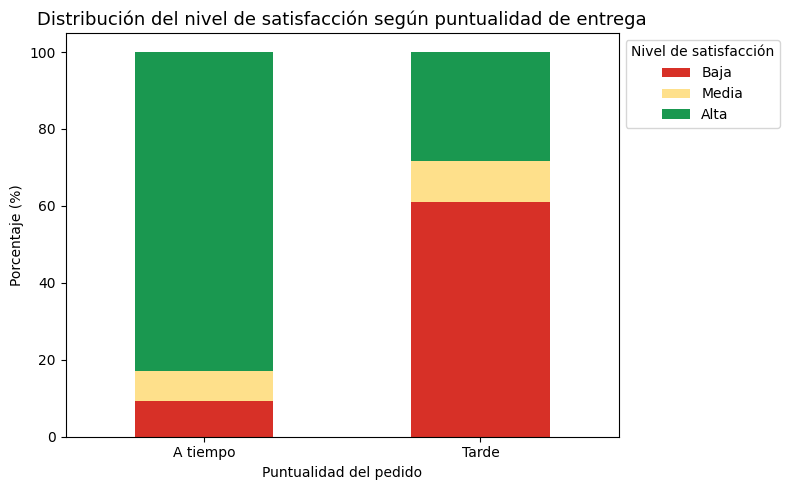

In [52]:
import matplotlib.pyplot as plt

pivot = grafico_reviews.pivot(index='puntualidad', columns='nivel_review', values='porcentaje')

ax = pivot[['Baja','Media','Alta']].plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    color=['#d73027','#fee08b','#1a9850']
)

plt.title("Distribución del nivel de satisfacción según puntualidad de entrega", fontsize=13)
plt.ylabel("Porcentaje (%)")
plt.xlabel("Puntualidad del pedido")
plt.legend(title="Nivel de satisfacción", bbox_to_anchor=(1,1))

# Rotar etiquetas del eje X a horizontal
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


La mayoría de pedidos entregados a tiempo reciben valoraciones altas con un 82.8% de reviews positivas, mientras que solo un pequeño porcentaje tiene calificaciones bajas o medias. En cambio, en los pedidos que llegan tarde apenas el 28,3% son reviews altas y la mayoría, 61,4%, son bajas. 

Por tanto, los pedidos demorados reciben muchas más reviews negativas que los entregados a tiempo: 61% frente a 9%.

Esto evidencia que los retrasos aumentan de manera significativa la probabilidad de recibir una review negativa. 

Garantizar la puntualidad es, por tanto, clave para aumentar la satisfacción y fidelización del cliente.


- ⚠️ Vamos a ver qué puede explicar que haya un 28% de clientes que sigan valorando positivamente pedidos demorados:

Categorías:

In [53]:
#Merge para añadir "product_id" al df "score_demorados":

score_demorados = score_demorados.merge(
    order_items[["order_id", "product_id"]],
    on="order_id",
    how="left"
)

In [54]:
# Merge para añadir la categoría producto a "score_demorados":
score_demorados = score_demorados.merge(
    products[["product_id", "product_category_name_english"]],
    on="product_id",
    how="left"
)

In [55]:
score_demorados= score_demorados.merge(df_grafico_reviews[["order_id","puntualidad"]], on="order_id", how="left")

In [56]:
score_demorados= score_demorados.merge(df_grafico_reviews[["order_id","nivel_review"]], on="order_id", how="left")

In [62]:
score_demorados= score_demorados.drop(columns=["puntualidad_y"]).rename(columns={"puntualidad_x":"puntualidad"})


In [63]:
# Filtramos por pedidos demorados con reviews altas:
reviews_demoradas_altas = score_demorados[(score_demorados["puntualidad"]=="Tarde") & (score_demorados["nivel_review"]=="Alta")]

In [65]:
# Filtramos por categoría de producto:
reviews_demoradas_altas = reviews_demoradas_altas.groupby("product_category_name_english").size().sort_values(ascending=False).reset_index(name="num_pedidos")
reviews_demoradas_altas.head(10)


,product_category_name_english,num_pedidos
0,health_beauty,223
1,bed_bath_table,220
2,furniture_decor,173
3,computers_accessories,147
4,sports_leisure,142
5,watches_gifts,108
6,housewares,94
7,telephony,93
8,auto,90
9,garden_tools,87


INSIGHT: Algunas categorías parecen compensar los retrasos con alta calidad percibida o valor del producto, haciendo que los clientes sigan dejando reviews positivas. Esto ayuda a explicar parte del 28% de reviews altas en pedidos demorados.

In [66]:
# Filtramos solo pedidos demorados:
total_demorados_categoria = score_demorados[score_demorados["puntualidad"]=="Tarde"]

# Total de pedidos tardíos por categoría:
total_demorados_categoria = total_demorados_categoria.groupby("product_category_name_english").size().reset_index(name="total_pedidos")

In [67]:
porcentaje_altas = reviews_demoradas_altas.merge(total_demorados_categoria, on="product_category_name_english")

In [68]:
porcentaje_altas["pct_altas"] = porcentaje_altas["num_pedidos"] / porcentaje_altas["total_pedidos"] * 100
porcentaje_altas = porcentaje_altas.sort_values(by="pct_altas", ascending=False)
porcentaje_altas.head(10)

,product_category_name_english,num_pedidos,total_pedidos,pct_altas
56,fashion_sport,1,1,100.000000
50,fashio_female_clothing,2,3,66.666667
28,christmas_supplies,10,15,66.666667
36,costruction_tools_tools,4,6,66.666667
21,books_general_interest,18,33,54.545455
26,books_technical,11,21,52.380952
51,cine_photo,2,4,50.000000
33,industry_commerce_and_business,8,17,47.058824
22,home_appliances,14,34,41.176471
32,construction_tools_lights,9,22,40.909091


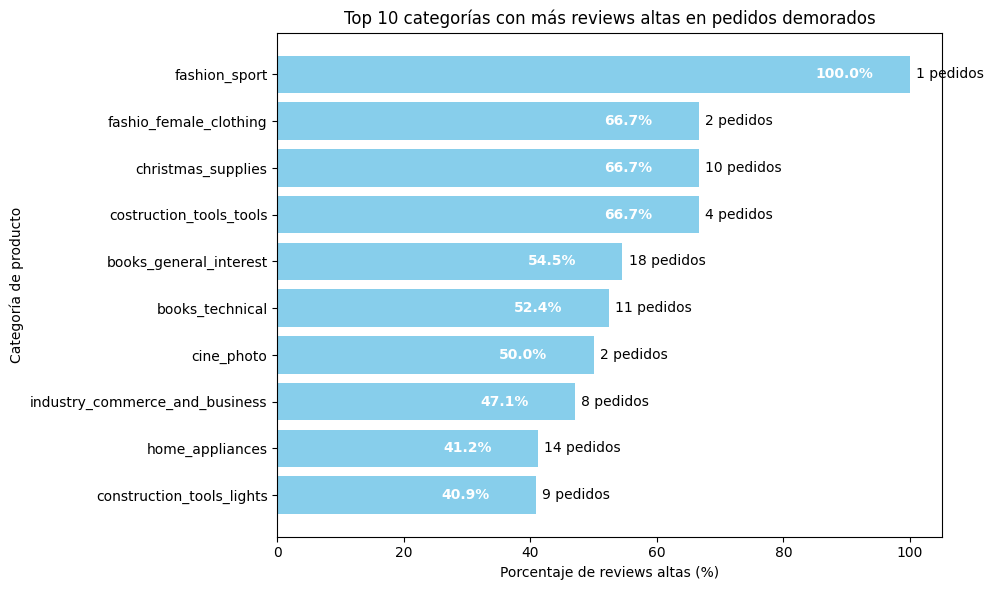

In [69]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# Seleccionamos top 10 por porcentaje
top10 = porcentaje_altas.sort_values(by="pct_altas", ascending=False).head(10)
categorias = top10["product_category_name_english"]
pct_altas = top10["pct_altas"]
num_pedidos = top10["num_pedidos"]

# Gráfico horizontal más visual
plt.figure(figsize=(10,6))
bars = plt.barh(categorias[::-1], pct_altas[::-1], color="skyblue")  # invertimos para que la mayor esté arriba

# Añadimos etiquetas con número de pedidos
for bar, pedidos, pct in zip(bars, num_pedidos[::-1], pct_altas[::-1]):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f"{pedidos} pedidos", va="center")
    plt.text(bar.get_width() - 15, bar.get_y() + bar.get_height()/2, f"{pct:.1f}%", va="center", color="white", weight="bold")

plt.xlabel("Porcentaje de reviews altas (%)")
plt.ylabel("Categoría de producto")
plt.title("Top 10 categorías con más reviews altas en pedidos demorados")
plt.xlim(0, 105)
plt.tight_layout()
plt.show()

CONCLUSIÓN:

Aunque categorías como fashion_sport muestra un 100% de reviews altas, este resultado se debe a un bajo volumen de pedidos, no a una satisfacción generalizada.


En cambio, categorías como productos de moda, temporada o herramientas específicas rondan 66-67% de satisfacción. Otras como books_general_interest (≈54%), books_technical (≈52%), home_appliances (≈41%) y construction_tools_lights (≈41%) siguen mostrando que una parte significativa de los clientes pone reviews positivas a pesar de la demora.


Algunas categorías logran mantener buena valoración a pesar de retrasos, lo que podría explicar parcialmente el 28% de pedidos demorados que aun así reciben reviews altas .S in embargo, existen otras categorías que se ven muy afectadas por la demora, lo que evidencia que la naturaleza del producto influyen significativamente en la satisfacción del cliente.

In [70]:
promedio_score_demorados= score_demorados["review_score"].mean()
print("Puntuación promedia de los pedidos demorados es", promedio_score_demorados)

Puntuación promedia de los pedidos demorados es 2.2515783694757068


Sellers:

In [71]:
# Añadir seller_id al df de reviews:
reviews_sellers = df_grafico_reviews.merge(
    order_items[["order_id", "seller_id"]],
    on="order_id",
    how="left"
)


In [72]:
reviews_altas_demoradas = reviews_sellers[
    (reviews_sellers["puntualidad"] == "Tarde") &
    (reviews_sellers["nivel_review"] == "Alta")
]

In [73]:
reviews_por_seller= reviews_altas_demoradas.groupby("seller_id").size().reset_index(name="num_pedidos_altas_demoradas")
reviews_por_seller = reviews_por_seller.sort_values(by="num_pedidos_altas_demoradas", ascending=False)

In [74]:
# Total de pedidos con review alta y demora:
total_reviews_altas_demoradas = reviews_por_seller["num_pedidos_altas_demoradas"].sum()
reviews_por_seller["porcentaje_sellers"] = (reviews_por_seller["num_pedidos_altas_demoradas"] / total_reviews_altas_demoradas) * 100
reviews_por_seller.head(10)

,seller_id,num_pedidos_altas_demoradas,porcentaje_sellers
110,1f50f920176fa81dab994f9023523100,49,2.374031
212,4a3ca9315b744ce9f8e9374361493884,47,2.277132
584,da8622b14eb17ae2831f4ac5b9dab84a,32,1.550388
633,ea8482cd71df3c1969d7b9473ff13abc,31,1.501938
428,955fee9216a65b617aa5c0531780ce60,30,1.453488
287,6560211a19b47992c3666cc44a7e94c0,28,1.356589
50,1025f0e2d44d7041d6cf58b6550e0bfa,26,1.259690
25,06a2c3af7b3aee5d69171b0e14f0ee87,26,1.259690
209,4869f7a5dfa277a7dca6462dcf3b52b2,26,1.259690
548,cc419e0650a3c5ba77189a1882b7556a,24,1.162791


- Distribución por número de reviews altas: 

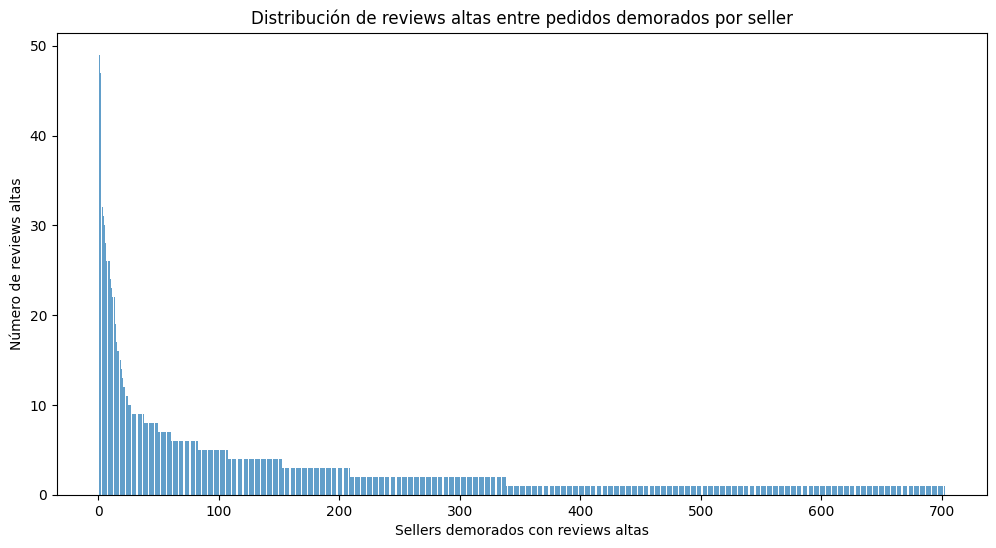

In [75]:
import matplotlib.pyplot as plt

# Ordenamos de mayor a menor
df = reviews_por_seller.sort_values("num_pedidos_altas_demoradas", ascending=False)

plt.figure(figsize=(12,6))
plt.bar(range(1, len(df)+1), df["num_pedidos_altas_demoradas"], alpha=0.7)
plt.xlabel("Sellers demorados con reviews altas")
plt.ylabel("Número de reviews altas")
plt.title("Distribución de reviews altas entre pedidos demorados por seller")
plt.show()


- Distribución por porcentaje de reviews altas: 

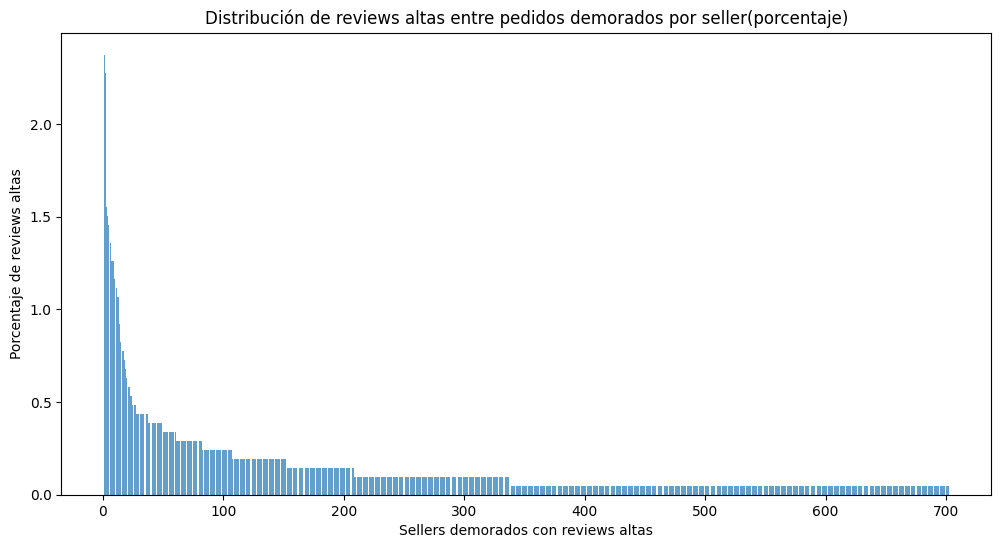

In [76]:
import matplotlib.pyplot as plt

# Ordenamos de mayor a menor
df = reviews_por_seller.sort_values("porcentaje_sellers", ascending=False)

plt.figure(figsize=(12,6))
plt.bar(range(1, len(df)+1), df["porcentaje_sellers"], alpha=0.7)
plt.xlabel("Sellers demorados con reviews altas")
plt.ylabel("Porcentaje de reviews altas")
plt.title("Distribución de reviews altas entre pedidos demorados por seller(porcentaje)")
plt.show()


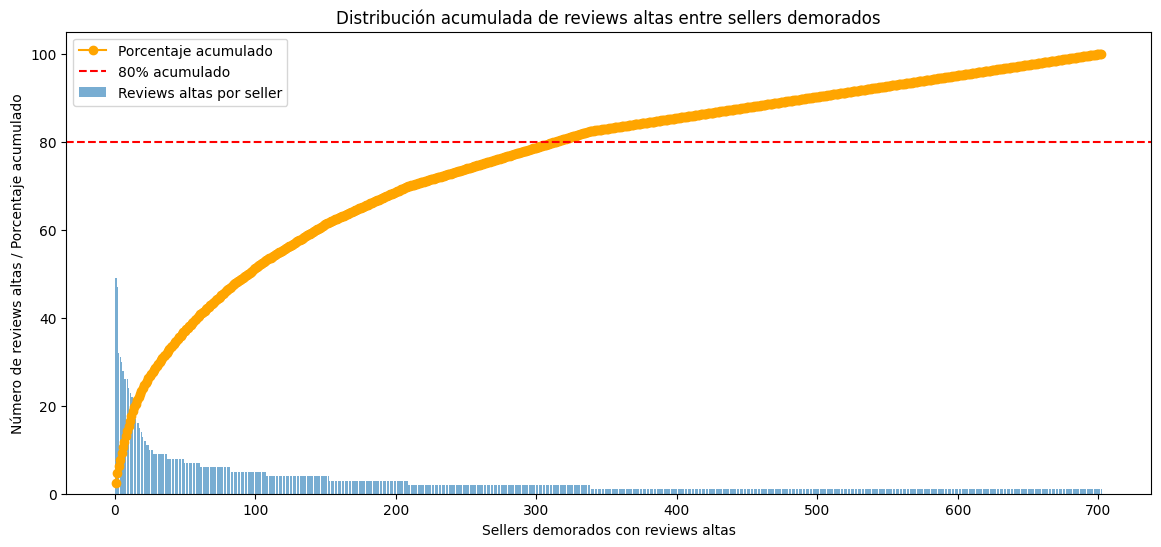

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Ordenamos los sellers de mayor a menor según reviews altas
df = reviews_por_seller.sort_values("num_pedidos_altas_demoradas", ascending=False).copy()

# Porcentaje acumulado
df["porcentaje_acumulado"] = np.cumsum(df["num_pedidos_altas_demoradas"]) / df["num_pedidos_altas_demoradas"].sum() * 100

# Gráfico combinado
plt.figure(figsize=(14,6))

# Barras
plt.bar(range(1, len(df)+1), df["num_pedidos_altas_demoradas"], alpha=0.6, label="Reviews altas por seller")

# Línea acumulada
plt.plot(range(1, len(df)+1), df["porcentaje_acumulado"], color="orange", marker="o", label="Porcentaje acumulado")

# Línea 80%
plt.axhline(80, color="red", linestyle="--", label="80% acumulado")

plt.xlabel("Sellers demorados con reviews altas")
plt.ylabel("Número de reviews altas / Porcentaje acumulado")
plt.title("Distribución acumulada de reviews altas entre sellers demorados")
plt.legend()
plt.show()


In [78]:
num_sellers= len(sellers)
print("Existen",num_sellers,"sellers activos")

Existen 3095 sellers activos


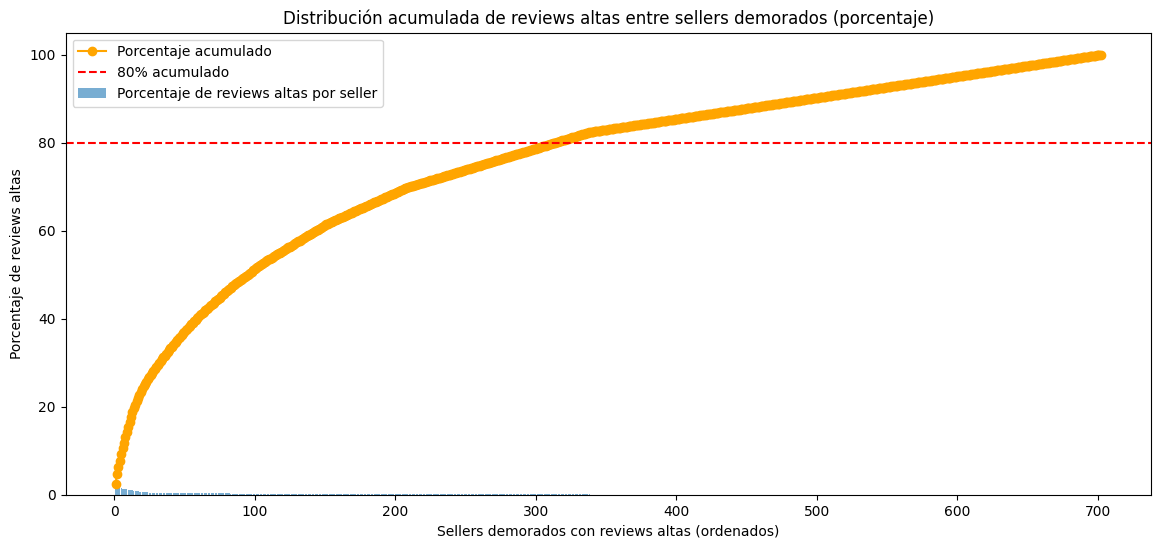

In [79]:
import matplotlib.pyplot as plt
import numpy as np

# Ordenamos los sellers de mayor a menor según porcentaje_sellers
df_pct = reviews_por_seller.sort_values("porcentaje_sellers", ascending=False).copy()

# Porcentaje acumulado
df_pct["porcentaje_acumulado"] = np.cumsum(df_pct["porcentaje_sellers"])

# Gráfico combinado
plt.figure(figsize=(14,6))

# Barras: porcentaje individual de cada seller
plt.bar(range(1, len(df_pct)+1), df_pct["porcentaje_sellers"], alpha=0.6, label="Porcentaje de reviews altas por seller")

# Línea acumulada
plt.plot(range(1, len(df_pct)+1), df_pct["porcentaje_acumulado"], color="orange", marker="o", label="Porcentaje acumulado")

# Línea 80%
plt.axhline(80, color="red", linestyle="--", label="80% acumulado")

plt.xlabel("Sellers demorados con reviews altas (ordenados)")
plt.ylabel("Porcentaje de reviews altas")
plt.title("Distribución acumulada de reviews altas entre sellers demorados (porcentaje)")
plt.legend()
plt.show()


En el df "reviews_por_seller" ya se ve que hay 702 sellers demorados. En los gráficos distribuidos por nº de reviews altas y porcentaje de reviews altas se puede ver que los primeros sellers concentran el mayor nº y porcentaje de reviews altas en pedidos demorados. Sin embargo, se puede apreciar que a partir de los 300 sellers, las reviews altas son prácticamente nulas. 

En los segundos gráficos de distribución ACUMULADA de reviews altas, se observa que la curva acumulada naranja aumenta con fuerza al principio y después empieza a estabilizarse una vez pasado el 80% acumulado de reviews altas, es decir, a partir de los 314 sellers. Esto demuestra que las reviews altas no se concentran en unos pocos sellers, sino que se distribuyen entre muchos sellers.

Esto podría explicar parte del 28% de reviews altas en pedidos demorados, pues existen muchos sellers que reciben muchas valoraciones positivas.

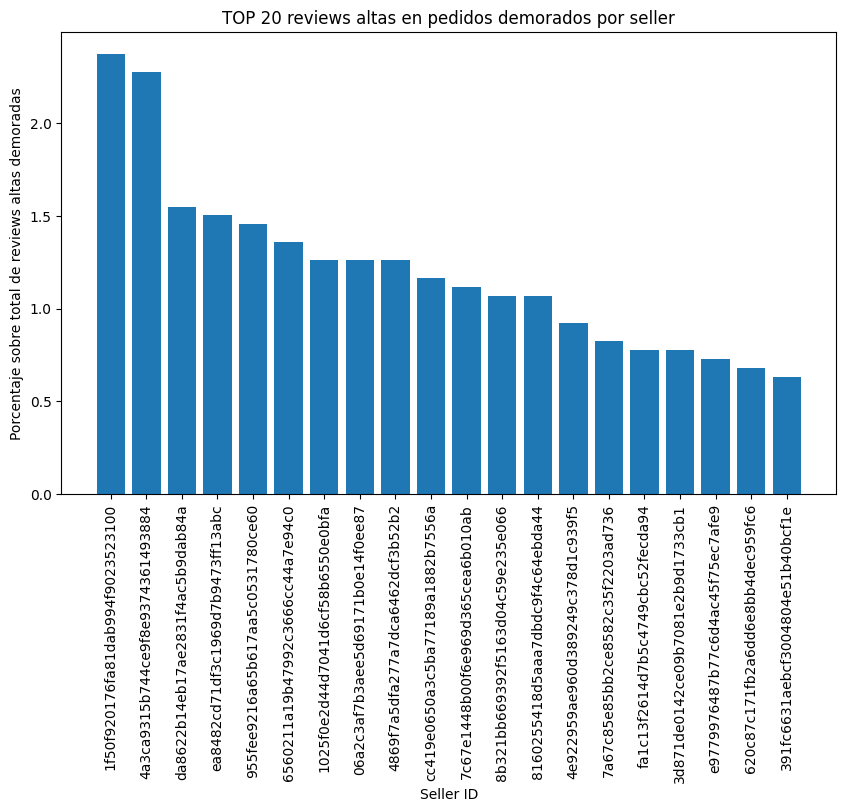

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(reviews_por_seller["seller_id"].head(20), reviews_por_seller["porcentaje_sellers"].head(20))
plt.xticks(rotation=90)
plt.title("TOP 20 reviews altas en pedidos demorados por seller")
plt.ylabel("Porcentaje sobre total de reviews altas demoradas")
plt.xlabel("Seller ID")
plt.show()


Como se observa en el gráfico, todos los valores son bastante pequeños, ningún seller representa más del 3% del total de pedidos demorados con reviews altas(4-5). Esto indica que las reviews altas se distribuyen bastante entre muchos sellers, aunque algunos destacan un poco más.

Existen pocos pedidos con reviews altas por seller, ya que incluso el seller con más pedidos solo tiene un 2.37% del total, por lo que no hay un seller dominante que concentre todas las reviews positivas. Sí es cierto que hay sellers que logran más reviews altas , podría ser porque manejan mejor la experiencia del cliente a pesar de la demora.

### Vamos a ver las categorías más afectadas por los sellers demorados:

In [81]:
# Filtramos order_items solo para los pedidos demorados
demorados_pedidos = order_items[order_items["order_id"].isin(score_demorados["order_id"])]

In [82]:
reviews_altas = score_demorados[score_demorados["review_score"].isin([4,5])]

In [83]:
reviews_altas =reviews_altas.merge(order_items[["order_id", "seller_id"]], on="order_id", how="left")

In [84]:
num_pedidos_altas_demoradas = (reviews_altas.groupby(["seller_id", "product_category_name_english"]) .size().reset_index(name="num_pedidos_altas_demoradas"))

In [85]:
total_demorados_por_seller = (
    score_demorados.merge(order_items[["order_id", "seller_id"]], on="order_id", how="left")
    .groupby("seller_id")
    .size()
    .reset_index(name="total_pedidos_demorados")
)


In [86]:
df_sellers = num_pedidos_altas_demoradas.merge(total_demorados_por_seller, on="seller_id")
df_sellers["porcentaje_seller"] = (df_sellers["num_pedidos_altas_demoradas"] / df_sellers["total_pedidos_demorados"]) * 100


In [87]:
df_sellers.sort_values("porcentaje_seller", ascending=False).reset_index().head(30)

,index,seller_id,product_category_name_english,num_pedidos_altas_demoradas,total_pedidos_demorados,porcentaje_seller
0,296,582d4f8675b945722eda7c0cb61ba4c7,electronics,1,1,100.0
1,163,2b5ed0c9139dae8883a200dfcb272ece,stationery,1,1,100.0
2,423,7b8e8ec35bad4b0ef7e3963650b0a87b,auto,1,1,100.0
3,149,271b8923c6a549e02d3c9fd1f8c0422b,construction_tools_construction,1,1,100.0
4,659,d1aa1ec0839dcab73a6161130eb1f94a,furniture_decor,1,1,100.0
5,416,7a91bf945c6fae0779f1c61ce97fe45c,health_beauty,1,1,100.0
6,660,d1b65fc7debc3361ea86b5f14c68d2e2,luggage_accessories,1,1,100.0
7,410,79565f7d5603b24ddf07ade262547f2f,auto,2,2,100.0
8,158,2a5b78b41cd05baeac8df54c6606b92c,health_beauty,1,1,100.0
9,405,76ea5315acb3f5f7ade3cd261faf922a,food,1,1,100.0


Ver cuántos registros tienen 100 % de reviews altas en el "df_sellers":

In [88]:
pedidos_100_reviews = (df_sellers["porcentaje_seller"] == 100).sum()

print(f"Número de registros con 100% de reviews altas: {pedidos_100_reviews}")


Número de registros con 100% de reviews altas: 170


In [89]:
# Filtramos registros con solo 1 pedido demorado y 100% reviews:
registros_100pct = df_sellers[
    (df_sellers["num_pedidos_altas_demoradas"] == 1) & 
    (df_sellers["total_pedidos_demorados"] == 1)
]

num_registros_100pct = len(registros_100pct)
print(f"Número de registros con 100% de reviews altas por tener solo 1 pedido: {num_registros_100pct}")


Número de registros con 100% de reviews altas por tener solo 1 pedido: 135


Es decir, que de los 170 registros que hay con 100% reviews altas, 135 de ellos tuvieron 1 solo pedido total que se demoró que puso buena review.

- Estos 135 registros representan casos aislados que inflan los porcentajes de 100% en df de categorías por seller. Así que vamos a filtrar por sellers con más de un pedido demorado:

In [90]:
# Filtrar solo sellers/categorías con más de un pedido demorado:
df_sellers_filtrado = df_sellers[df_sellers["total_pedidos_demorados"] > 1]

#Recalculamos porcentaje de pedidos altos:
df_sellers_filtrado["porcentaje_seller"] = (
    df_sellers_filtrado["num_pedidos_altas_demoradas"] / df_sellers_filtrado["total_pedidos_demorados"] * 100
)

# Revisamos cuántos registros nos quedan:
print(f"Número de registros con más de 1 pedido demorado: {len(df_sellers_filtrado)}")

Número de registros con más de 1 pedido demorado: 682


/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/2400157619.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sellers_filtrado["porcentaje_seller"] = (


In [91]:
df_sellers_filtrado= df_sellers_filtrado.sort_values(by="num_pedidos_altas_demoradas",ascending=False).copy()
df_sellers_filtrado.head(20)

,seller_id,product_category_name_english,num_pedidos_altas_demoradas,total_pedidos_demorados,porcentaje_seller
128,1f50f920176fa81dab994f9023523100,garden_tools,69,221,31.221719
244,4a3ca9315b744ce9f8e9374361493884,bed_bath_table,45,251,17.928287
54,1025f0e2d44d7041d6cf58b6550e0bfa,furniture_decor,41,155,26.451613
424,7c67e1448b00f6e969d365cea6b010ab,office_furniture,41,255,16.078431
55,1127b7f2594683f2510f1c2c834a486b,garden_tools,37,37,100.000000
477,8a32e327fe2c1b3511609d81aaf9f042,furniture_decor,37,42,88.095238
320,6039e27294dc75811c0d8a39069f52c0,computers_accessories,36,46,78.260870
746,ec8463980a4e0ea9f8517aea1ed0c419,construction_tools_lights,36,36,100.000000
741,ea8482cd71df3c1969d7b9473ff13abc,telephony,30,108,27.777778
505,955fee9216a65b617aa5c0531780ce60,furniture_decor,29,161,18.012422


Aunque hay más de 680 sellers con pedidos demorados, solo un grupo reducido de sellers concentra la mayoría de las reviews altas, cuyos tipos de producto están concentrados en garden_tools,furniture_decor, bed_bath_table y office_furniture.

Por ejemplo, el seller con ID 1f50f920176fa81dab994f9023523100 de la categoría garden_tools tiene 69 pedidos demorados con reviews altas, representando un 31,2% de sus pedidos demorados totales. Esto indica que una minoría de vendedores logra mantener buena reputación incluso con demoras, posiblemente por ofrecer buena atención o productos de calidad.

También, existen casos excepcionales de satisfacción 100% como el seller ID 1127b7f2594683f2510f1c2c834a486b de la categoría garden_tools también,que tiene un 100% de reviews altas en pedidos demorados. Esto sugiere que la categoría o el tipo de producto puede influir en la tolerancia del cliente al retraso, especialmente si la calidad percibida del producto es alta.


En general, existe una amplia variabilidad entre vendedores, pues el porcentaje de reviews altas en pedidos demorados varía mucho: desde menos del 10% hasta 100%, lo que evidencia una fuerte dispersión en la percepción del servicio según el vendedor.Esto apunta a que el manejo individual del vendedor tiene un papel relevante en la satisfacción final.

CONCLUSIONES:

Los mismos sellers (por ejemplo 1f50f9..., 4a3ca9..., da8622...) aparecen también entre los Top 20 del gráfico de reviews altas en pedidos demorados.

Los sellers 1f50f9... (garden_tools) con 31% de sus pedidos demorados tuvieron reviews altas, 4a3ca9... (bed_bath_table) con casi un 18% o 1025f0... (furniture_decor)con un 26%, aun teniendo retrasos frecuentes, logran amortiguar el impacto de demora(puede ser por buena atención, seguimiento o por la calidad percibida por el cliente del producto).

Hay otras categorías como garden_tools y furniture_decor que tienen varios sellers con porcentajes altos de reviews positivas pese a demoras, ya que el cliente tolera más estos productos si el producto cumple expectativas. Otras categorías (como electronics o telephony) muestran porcentajes más bajos (~20–28%),
lo que implica que los retrasos afectan más negativamente la experiencia.

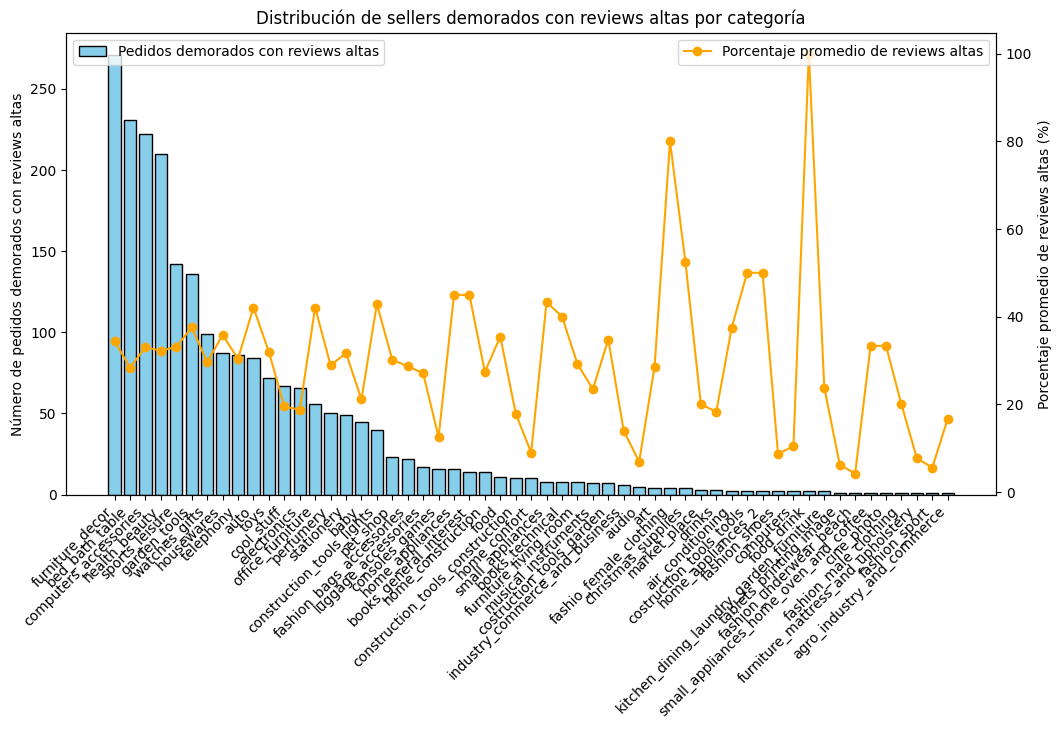

In [92]:
import matplotlib.pyplot as plt
import pandas as pd

# Agrupamos por categoría:
df_cat_seller= df_sellers_filtrado.groupby("product_category_name_english").agg({
    "num_pedidos_altas_demoradas": "sum",
    "porcentaje_seller": "mean"
}).sort_values("num_pedidos_altas_demoradas", ascending=False)

fig, ax1 = plt.subplots(figsize=(12,6))

# Barras: número de pedidos demorados con reviews altas:
ax1.bar(df_cat_seller.index, df_cat_seller["num_pedidos_altas_demoradas"], color="skyblue", edgecolor="black", label="Pedidos demorados con reviews altas")
ax1.set_ylabel("Número de pedidos demorados con reviews altas")
ax1.set_xticks(range(len(df_cat_seller)))
ax1.set_xticklabels(df_cat_seller.index, rotation=45, ha="right")

# Línea: porcentaje promedio de reviews altas:
ax2 = ax1.twinx()
ax2.plot(df_cat_seller.index, df_cat_seller["porcentaje_seller"], color="orange", marker="o", label="Porcentaje promedio de reviews altas")
ax2.set_ylabel("Porcentaje promedio de reviews altas (%)")

plt.title("Distribución de sellers demorados con reviews altas por categoría")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()


El análisis muestra que categorías como furniture_decor, bed_bath_table, health_beauty y computers_accessories concentran la mayoría de los sellers con pedidos demorados que aun así reciben valoraciones altas. Esto indica que la satisfacción del cliente no depende solo de la puntualidad, sino también de la calidad del producto o del servicio postventa.

Se observa un pico del 100% de reviews positivas en categorías con pocos pedidos, como kitchen_dining_laundry_garden_furniture. Este resultado se explica por el bajo volumen de pedidos, por lo que no es representativo.

Por otro lado, categorías con mayor volumen y porcentajes medios de satisfacción como office_furniture o construction_tools_lights destacan por mantener buena percepción pese a los retrasos, lo que sugiere buena atención al cliente.

En conjunto, los resultados confirman que la satisfacción del cliente en Olist no está determinada únicamente por la rapidez del envío, sino por una combinación de factores que varían según la categoría y el desempeño del vendedor.

### Promedio de días de entrega en función de su review_score:


In [93]:
# Traemos días_entrega desde orders_entregados:
score_demorados = score_demorados.merge(
    orders_entregados[["order_id", "días_entrega"]],
    on="order_id",
    how="left"
)


In [97]:
# Agrupamos por review_score y calculamos promedio de días de entrega:

promedio_dias_por_score = score_demorados.groupby("review_score")["días_entrega"].mean().reset_index()

promedio_dias_por_score

,review_score,días_entrega
0,1.0,35.807217
1,2.0,33.622433
2,3.0,31.637066
3,4.0,29.669444
4,5.0,28.243085


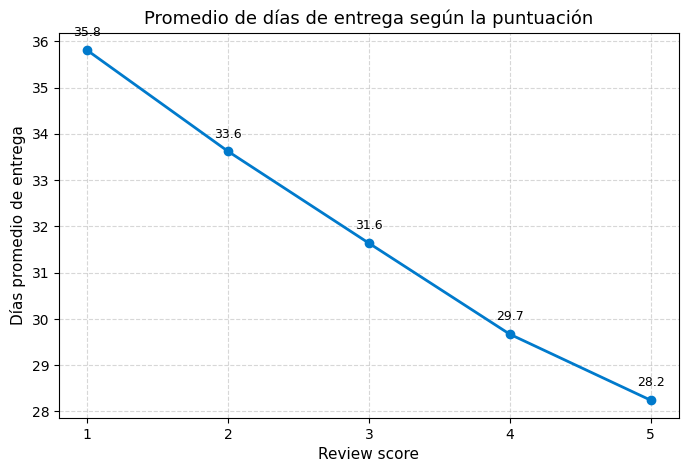

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(promedio_dias_por_score["review_score"], promedio_dias_por_score["días_entrega"], 
         marker="o", color="#007acc", linewidth=2)

# Etiquetas
for i, row in promedio_dias_por_score.iterrows():
    plt.text(row["review_score"], row["días_entrega"]+0.3, f"{row['días_entrega']:.1f}", 
             ha="center", fontsize=9)

plt.title("Promedio de días de entrega según la puntuación", fontsize=13)
plt.xlabel("Review score", fontsize=11)
plt.ylabel("Días promedio de entrega", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(range(1,6))
plt.show()


A medida que aumentan los días de entrega, la satisfacción del cliente baja, por lo que hay una relación bastante directa entre demora y puntuación. Los pedidos con puntuaciones bajas (1–2) tardan de media 6–8 días más que los que reciben reviews altas (4–5).



### Relación entre "reviews" y días de retraso en entrega:

In [110]:
score_demorados_limpio = score_demorados.dropna(subset=["review_score"])

- Porcentaje de review baja (1 o 2) por rango de retraso:

In [112]:
# Porcentaje de review baja (1 o 2) por rango de retraso
porcentaje_review_baja = score_demorados_limpio.groupby("rango_retraso").apply(
    lambda x: (x["review_score"].isin([1,2]).sum() / len(x)) * 100
).reset_index(name="porcentaje_review_baja")

porcentaje_review_baja


/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/3980301998.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  porcentaje_review_baja = score_demorados_limpio.groupby("rango_retraso").apply(


,rango_retraso,porcentaje_review_baja
0,1-2 días,27.406932
1,3-6 días,62.568716
2,7+ días,78.266702


Cuando los pedidos llegan entre 1 y 2 días tarde, los clientes quedan totalmente satisfechos pero cuando se demoran entre 3 y 6 días tarde, algunos clientes ya se empiezan a quejar. En cambio, cuando tardan más de una semana, la mayoría de clientes (61,5%) están molestos y dejan una mala review. 

El número de reviews bajas aumenta drásticamente con el retraso, pues pasa del 27 % en 1-2 días a más del 78 % en retrasos de 7 días o más. Esto confirma que los retrasos largos impactan fuertemente en la satisfacción del cliente y que reducir demoras mayores a 2 días podría mejorar significativamente la experiencia.

- Porcentaje de review media (3) por rango de retraso:

In [113]:
# Porcentaje de review media (3) por rango de retraso:
porcentaje_review_media = score_demorados_limpio.groupby("rango_retraso").apply(
    lambda x: (x["review_score"].isin([3]).sum() / len(x)) * 100
).reset_index(name="porcentaje_review_media")

porcentaje_review_media


/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/61557320.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  porcentaje_review_media = score_demorados_limpio.groupby("rango_retraso").apply(


,rango_retraso,porcentaje_review_media
0,1-2 días,14.890886
1,3-6 días,10.444778
2,7+ días,9.015294


Las reviews medias representan solo entre el 9 y 15 % de los pedidos demorados. Esto sugiere que los clientes tienden a polarizar sus opiniones, pues los retrasos largos casi siempre generan reviews bajas, mientras que las medias son poco frecuentes.


- Porcentaje de review alta (4,5) por rango de retraso:

In [114]:
# Calcular porcentaje de reviews altas (4,5) por rango de retraso:
porcentaje_review_alta = score_demorados_limpio.groupby("rango_retraso").apply(
    lambda x: (x["review_score"].isin([4,5]).sum() / len(x)) * 100
).reset_index(name="porcentaje_review_alta")
porcentaje_review_alta.head()

/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/182013965.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  porcentaje_review_alta = score_demorados_limpio.groupby("rango_retraso").apply(


,rango_retraso,porcentaje_review_alta
0,1-2 días,57.702182
1,3-6 días,26.986507
2,7+ días,12.718004


Las reviews altas disminuyen drásticamente a medida que aumenta el retraso, pues pasan del 58 % en 1-2 días a solo 13 % en retrasos de 7 días o más. Esto evidencia que la puntualidad es crítica para la percepción positiva del cliente y que incluso retrasos moderados reducen notablemente la probabilidad de recibir una review alta.

Se puede ver que a medida que aumentan los días de demora, las altas disminuyen, mientras que las bajas aumentan.Esto refuerza el patrón de polarización de la satisfacción: retrasos largos casi garantizan insatisfacción de los clientes.

In [117]:
# Unir las tres tablas en un solo df: 
porcentajes_reviews = (
    porcentaje_review_baja
    .merge(porcentaje_review_media, on="rango_retraso")
    .merge(porcentaje_review_alta, on="rango_retraso")
)

porcentajes_reviews

,rango_retraso,porcentaje_review_baja,porcentaje_review_media,porcentaje_review_alta
0,1-2 días,27.406932,14.890886,57.702182
1,3-6 días,62.568716,10.444778,26.986507
2,7+ días,78.266702,9.015294,12.718004


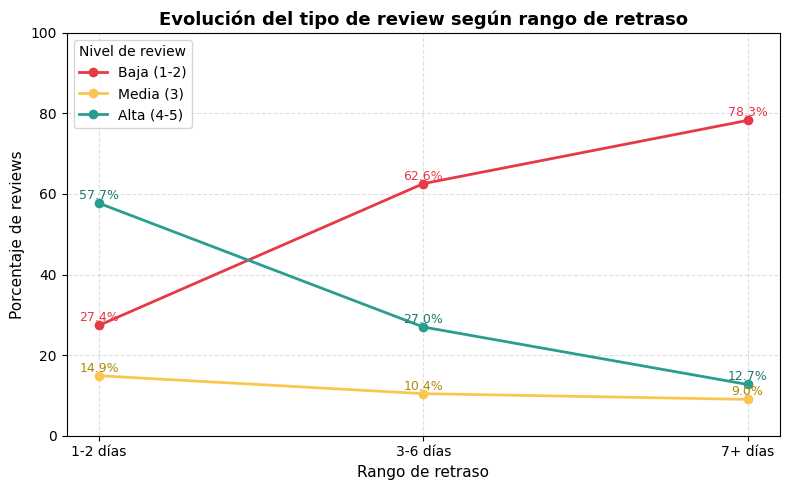

In [118]:
import matplotlib.pyplot as plt
import numpy as np

# Asegurarte de que está ordenado por rango
orden = ["1-2 días", "3-6 días", "7+ días"]
porcentajes_reviews = porcentajes_reviews.set_index("rango_retraso").loc[orden].reset_index()

rango = porcentajes_reviews["rango_retraso"]
baja = porcentajes_reviews["porcentaje_review_baja"]
media = porcentajes_reviews["porcentaje_review_media"]
alta = porcentajes_reviews["porcentaje_review_alta"]

plt.figure(figsize=(8,5))

plt.plot(rango, baja, marker="o", label="Baja (1-2)", color="#E63946", linewidth=2)
plt.plot(rango, media, marker="o", label="Media (3)", color="#F9C74F", linewidth=2)
plt.plot(rango, alta, marker="o", label="Alta (4-5)", color="#2A9D8F", linewidth=2)

# Etiquetas de porcentaje encima de cada punto:
for x, y in zip(rango, baja):
    plt.text(x, y+1, f"{y:.1f}%", ha="center", color="#E63946", fontsize=9)
for x, y in zip(rango, media):
    plt.text(x, y+1, f"{y:.1f}%", ha="center", color="#B08900", fontsize=9)
for x, y in zip(rango, alta):
    plt.text(x, y+1, f"{y:.1f}%", ha="center", color="#1B7C6C", fontsize=9)

plt.title("Evolución del tipo de review según rango de retraso", fontsize=13, weight="bold")
plt.xlabel("Rango de retraso", fontsize=11)
plt.ylabel("Porcentaje de reviews", fontsize=11)
plt.ylim(0, 100)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Nivel de review", frameon=True)
plt.tight_layout()
plt.show()


Se puede observar que las reviews bajas aumentan con el retraso, pasan del 27 % en 1-2 días al 63 % en 3-6 días y 78 % en 7+ días. Esto confirma que los retrasos largos generan insatisfacción significativa.

En cambio, las reviews altas caen drásticamente, ya que pasan del 58 % en 1-2 días al 27 % en 3-6 días y 13 % en 7+ días. La puntualidad es clave para mantener la experiencia positiva del cliente.


Por su parte, las reviews medias se mantienen bajas en todos los rangos, entre el 9 y 15 %, lo que muestra que las opiniones tienden a polarizarse, es decir, que son o bien positivas o negativas, con pocas intermedias.


Se ve, además, que a partir de 3 días de retraso, la insatisfacción crece notablemente y las reviews altas disminuyen a menos de la mitad, indicando que retrasos moderados ya impactan en la percepción del cliente.


CONCLUSIÓN: 

Cuando los pedidos se retrasan solo un par de días, los clientes son muy tolerantes y quedan satisfechos con su compra. A partir de tres días de demora empieza a notarse insatisfacción: más del 60% de clientes reaccionan negativamente, pasando de la neutralidad a malas valoraciones, aunque el 27% todavía mantiene una opinión positiva.

Cuando los pedidos se demoran más de una semana, la percepción del servicio se ve gravemente afectada: la mayoría de los clientes (78,3%) se siente frustrada y deja reviews negativas, mostrando que la puntualidad es clave para mantener la satisfacción.

En resumen, existe una relación directa entre la duración del retraso y la satisfacción: a mayor retraso, menor satisfacción, con impactos leves en retrasos cortos y graves en retrasos moderados y largos.

### Categorías más afectadas por los retrasos de entrega:

In [119]:
# Contamos categorías producto de pedidos demorados según rango de retraso y año:
categorias_por_retraso = score_demorados.groupby(["año", "rango_retraso", "product_category_name_english"]).size().reset_index(name="nº_demorados_categoria")

In [ ]:
#Contamos los pedidos demorados totales según rango de retraso y año:

categorias_por_retraso["total_pedidos_demorados"] = categorias_por_retraso.groupby(["año", "rango_retraso"])["nº_demorados_categoria"].transform("sum")

In [ ]:
#Calculamos porcentaje de cada categoría dentro del rango de retraso:
categorias_por_retraso["porcentaje_categoria"] = (
    categorias_por_retraso["nº_demorados_categoria"] / categorias_por_retraso["total_pedidos_demorados"] * 100
)



In [134]:
import pandas as pd

# Definir el orden cronológico de los rangos de retraso
categorias_por_retraso["rango_retraso"] = categorias_por_retraso["rango_retraso"].str.strip()

orden_retraso = ["1-2 días", "3-6 días", "7+ días"]

categorias_por_retraso["rango_retraso"] = pd.Categorical(
    categorias_por_retraso["rango_retraso"],
    categories=orden_retraso,
    ordered=True
)

# Ahora sí ordenamos por año y rango de retraso
categorias_por_retraso = categorias_por_retraso.sort_values(
    by="porcentaje_categoria",
    ascending=False
)

categorias_por_retraso.head(10)

,año,rango_retraso,product_category_name_english,nº_demorados_categoria,total_pedidos_demorados,porcentaje_categoria
0,2016,1-2 días,health_beauty,1,1,100.000000
2,2016,7+ días,health_beauty,3,4,75.000000
1,2016,7+ días,computers_accessories,1,4,25.000000
99,2017,7+ días,bed_bath_table,208,1448,14.364641
48,2017,3-6 días,bed_bath_table,103,733,14.051842
232,2018,3-6 días,health_beauty,158,1281,12.334114
7,2017,1-2 días,bed_bath_table,70,595,11.764706
286,2018,7+ días,health_beauty,270,2330,11.587983
24,2017,1-2 días,furniture_decor,68,595,11.428571
260,2018,7+ días,bed_bath_table,256,2330,10.987124


En 2016, los retrasos fueron mínimos pero concentrados: health_beauty representó el 80% de los pedidos demorados, mientras que computers_accessories solo 20%.

En 2017, los retrasos se distribuyen más entre varias categorías, aunque bed_bath_table (12,8%) y furniture_decor (10,3%) lideran, seguidas por health_beauty (7,7%) y sports_leisure (6,8%).

En 2018, los retrasos se concentran principalmente en health_beauty (11,4%), bed_bath_table (9,8%), computers_accessories (8,2%) y sports_leisure (7,8%), mostrando que ciertas categorías críticas acumulan más problemas logísticos año tras año.

Las categorías tecnológicas y de hogar (computers_accessories, telephony, furniture_decor) también presentan retrasos recurrentes, indicando que la complejidad del producto o el volumen afectan la eficiencia de los vendedores.

/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/4103349530.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


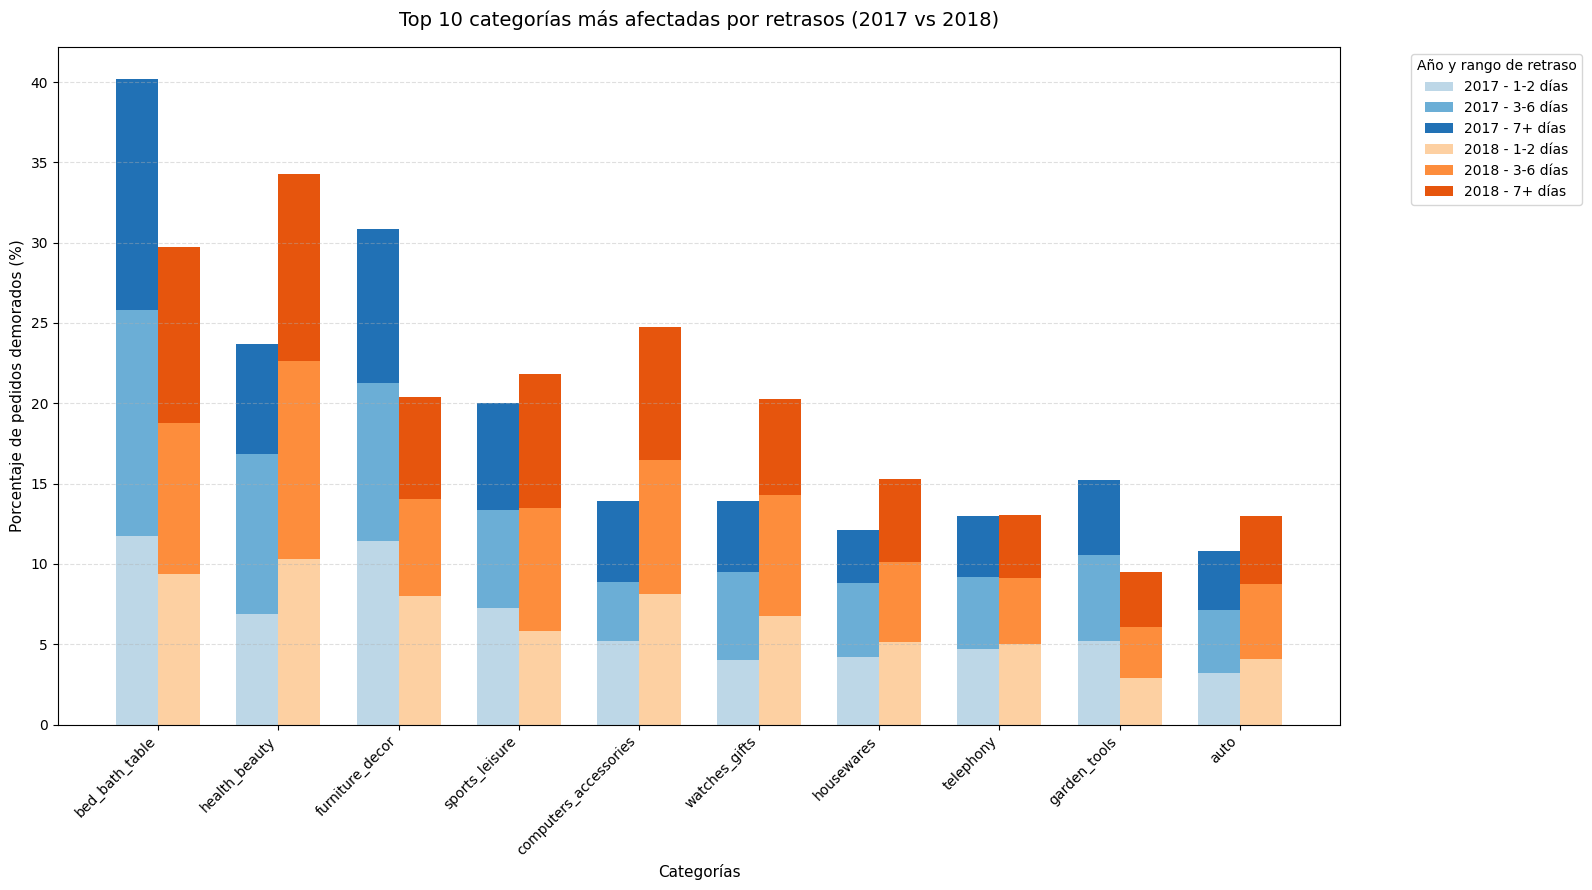

In [156]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dataframe filtrado:
df = categorias_por_retraso[categorias_por_retraso["año"].isin([2017, 2018])].copy()

# TOP 10 CATEGORÍAS:
top10 = (
    df.groupby("product_category_name_english")["porcentaje_categoria"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)
df = df[df["product_category_name_english"].isin(top10)]

# PIVOT :
pivot = df.pivot_table(
    index=["product_category_name_english", "año"],
    columns="rango_retraso",
    values="porcentaje_categoria",
    aggfunc="sum",
    fill_value=0
).reset_index()

# Aseguramos que estén todos los rangos
for rango in ["1-2 días", "3-6 días", "7+ días"]:
    if rango not in pivot.columns:
        pivot[rango] = 0

orden_categorias = (
    df.groupby("product_category_name_english")["porcentaje_categoria"]
    .mean()
    .sort_values(ascending=False)
    .index
)
pivot["product_category_name_english"] = pd.Categorical(
    pivot["product_category_name_english"], categories=orden_categorias, ordered=True
)
pivot = pivot.sort_values(["product_category_name_english", "año"])

# CONFIGURACIÓN DE GRÁFICO:
fig, ax = plt.subplots(figsize=(16, 9))
x = np.arange(len(orden_categorias))
width = 0.35  # ancho de barra por año

# Colores por año y rango:
colores_2017 = {"1-2 días": "#bdd7e7", "3-6 días": "#6baed6", "7+ días": "#2171b5"}
colores_2018 = {"1-2 días": "#fdd0a2", "3-6 días": "#fd8d3c", "7+ días": "#e6550d"}

for i, año in enumerate([2017, 2018]):
    data = pivot[pivot["año"] == año]
    bottoms = np.zeros(len(data))
    for rango in ["1-2 días", "3-6 días", "7+ días"]:
        colores = colores_2017 if año == 2017 else colores_2018
        ax.bar(
            x + (i - 0.5) * width,
            data[rango].values,
            width=width,
            bottom=bottoms,
            color=colores[rango],
            label=f"{año} - {rango}" 
        )
        bottoms += data[rango].values

# Formato:
ax.set_title("Top 10 categorías más afectadas por retrasos (2017 vs 2018)", fontsize=14, pad=15)
ax.set_xlabel("Categorías", fontsize=11)
ax.set_ylabel("Porcentaje de pedidos demorados (%)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(orden_categorias, rotation=45, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Año y rango de retraso", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


En la comparación entre 2017 y 2018, se observa que las categorías bed_bath_table, health_beauty y furniture_decor concentraron los mayores niveles de retraso, aunque con una ligera mejora en 2018.

En general, los retrasos largos de +7 días disminuyeron, mientras que los retrasos cortos (1–2 días)aumentaron, lo que sugiere una optimización en la logística de entrega.

Las categorías intermedias como sports_leisure o computers_accessories, mantuvieron una distribución más equilibrada entre los distintos rangos de demora.

Por otro lado, housewares, telephony y auto presentaron los menores niveles de retraso, con mejoras visibles en 2018.

En resumen, la tendencia apunta a una reducción progresiva de los retrasos graves y una mejora general del cumplimiento de plazos entre 2017 y 2018.


### COMPROBACIÓN DE Nº PEDIDOS DEMORADOS EN PERIODO 1-05-2018 A 31-06-2018:

In [248]:
# Asegurarnos de que las fechas son datetime:
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])


In [249]:
# Filtrar pedidos demorados (entregados después de la fecha estimada):
orders["is_delayed"] = (
    orders["order_delivered_customer_date"].notna() &
    orders["order_estimated_delivery_date"].notna() &
    (orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"])
)

# Filtrar solo los pedidos demorados
demorados = orders[orders["is_delayed"]].copy()

In [250]:
demorados_2018 = demorados[demorados["order_delivered_customer_date"].dt.year == 2018].copy()

In [251]:
## Filtrar solo el periodo mayo-junio 2018 según fecha de entrega real:

inicio_periodo = pd.to_datetime("2018-05-01")
fin_periodo = pd.to_datetime("2018-06-30")

demorados_periodo = demorados_2018[
    (demorados_2018["order_delivered_customer_date"] >= inicio_periodo) &
    (demorados_2018["order_delivered_customer_date"] <= fin_periodo)
].copy()

In [252]:
# Número de pedidos demorados en el periodo:

num_demorados_periodo = len(demorados_periodo)
num_demorados_total_2018 = len(demorados_2018)

In [253]:
porcentaje_demorados_periodo = (num_demorados_periodo / num_demorados_total_2018) * 100

print("Hay", num_demorados_periodo, "pedidos demorados en el periodo")
print("El porcentaje de demorados del periodo s/total demorados es", porcentaje_demorados_periodo)


Hay 1047 pedidos demorados en el periodo
El porcentaje de demorados del periodo s/total demorados es 18.446088794926006


Del total de pedidos demorados, el 18.45% del total ocurrieron durante el periodo desde 1 mayo 2018 hasta 30 junio 2018. Hubo 1047 pedidos atrasados durante ese periodo.

### Categorías que más retrasos tuvieron durante este periodo:

In [254]:
# Añadimos product_id y categoría
categorias_demoradas_periodo = (
    demorados_periodo
    .merge(order_items[["order_id", "product_id"]], on="order_id", how="left")
    .merge(products[["product_id", "product_category_name_english"]], on="product_id", how="left")
)

In [255]:
# Contamos por categoría en el periodo
categorias_demoradas_periodo = (
    categorias_demoradas_periodo.groupby("product_category_name_english")
    .size()
    .reset_index(name="num_demorados_periodo")
)

In [256]:
# Añadimos al df  categoría producto: 
categorias_demoradas_2018 = (
    demorados_2018
    .merge(order_items[["order_id","product_id"]], on="order_id", how="left")
    .merge(products[["product_id", "product_category_name_english"]], on="product_id", how="left")
)

In [257]:
# Contamos por categoría en todo 2018:
categorias_demoradas_2018 = (
    categorias_demoradas_2018.groupby("product_category_name_english")
    .size()
    .reset_index(name="num_demorados_total_2018")
)


In [258]:
# Merge periodo vs total
categorias_comparativo = categorias_demoradas_periodo.merge(
    categorias_demoradas_2018,
    on="product_category_name_english",
    how="left"
)

In [266]:
# Cálculo del porcentaje:
categorias_comparativo["porcentaje_periodo_sobre_total"] = (
    categorias_comparativo["num_demorados_periodo"] / categorias_comparativo["num_demorados_total_2018"] * 100
)

categorias_comparativo = categorias_comparativo.sort_values( by="num_demorados_periodo", ascending=False
)

top_10_cat= categorias_comparativo.head(10)
top_10_cat

,product_category_name_english,num_demorados_periodo,num_demorados_total_2018,porcentaje_periodo_sobre_total
34,health_beauty,149,656,22.713415
6,bed_bath_table,98,655,14.961832
30,furniture_decor,90,427,21.077283
55,watches_gifts,88,381,23.097113
51,sports_leisure,82,460,17.826087
38,housewares,72,336,21.428571
12,computers_accessories,55,473,11.627907
4,auto,53,257,20.622568
33,garden_tools,52,243,21.399177
22,electronics,38,213,17.840376


"Health_beauty" es la categoría que más retrasos tuvo durante ese periodo con 149 pedidos demorados, representando el 22.7% del total de pedidos demorados. Le siguen bed_bath_table con 98 pedidos(14.96%), furniture_decor 90 pedidos(21%) y watches_gifts con 88 pedidos(23.1%).
Esto indica que estas categorías fueron las que más contribuyeron a los retrasos en el periodo, destacando la categoría "watches_gifts" que fue la que más % de pedidos demorados tuvo en ese periodo.

El resto de categorías tienen porcentajes menores, lo que muestra que los problemas de entrega no están distribuidos de manera uniforme, sino concentrados en unas pocas categorías.

Categorías como electronics, garden_tools o auto tienen menos pedidos demorados que las categorías críticas, pero aun así, tienen un porcentaje bastante alto de pedidos demorados.


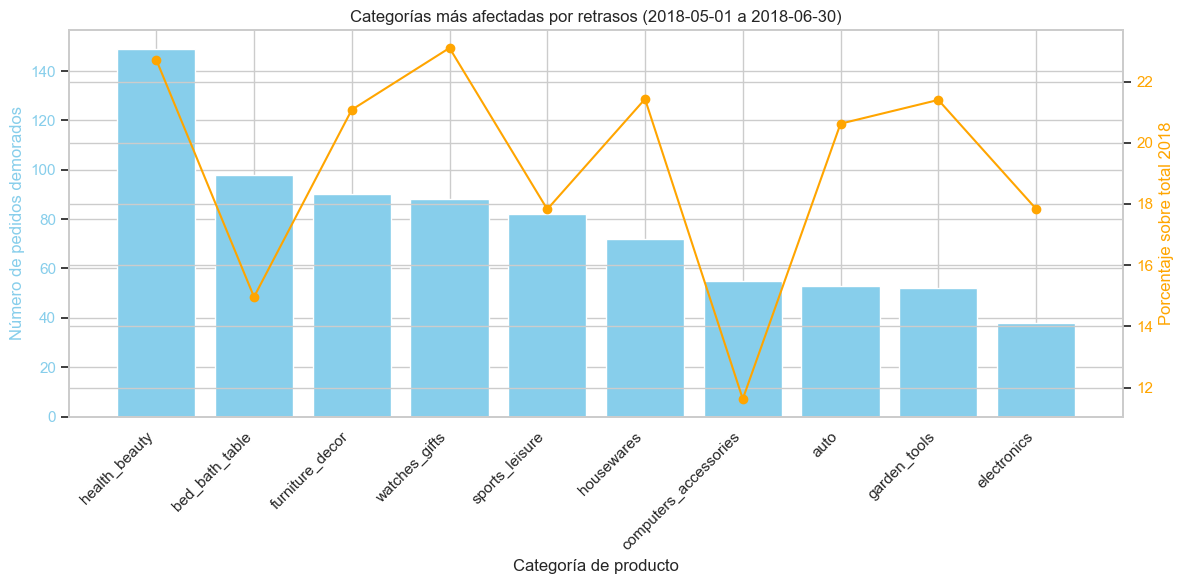

In [265]:
import matplotlib.pyplot as plt

categorias = top_10_cat["product_category_name_english"]
num_demorados = top_10_cat["num_demorados_periodo"]
porcentaje = top_10_cat["porcentaje_periodo_sobre_total"]

fig, ax1 = plt.subplots(figsize=(12,6))

# Barras del número de pedidos demorados:
ax1.bar(categorias, num_demorados, color="skyblue", label="Num demorados periodo")
ax1.set_xlabel("Categoría de producto")
ax1.set_ylabel("Número de pedidos demorados", color="skyblue")
ax1.tick_params(axis='y', labelcolor="skyblue")
plt.xticks(rotation=45, ha="right")

# Segundo eje y para el porcentaje:
ax2 = ax1.twinx()
ax2.plot(categorias, porcentaje, color="orange", marker="o", label="% sobre total 2018")
ax2.set_ylabel("Porcentaje sobre total 2018", color="orange")
ax2.tick_params(axis='y', labelcolor="orange")

# Título
plt.title("Categorías más afectadas por retrasos (2018-05-01 a 2018-06-30)")

fig.tight_layout()
plt.show()


En el gráfico se puede ver que la categoría más afectada por nº pedidos en ese periodo de 2018 fue "health_beauty" con más de 140 pedidos. Sin embargo, se puede apreciar que el punto más alto del % pedidos demorados fue de "watches_gifts" llegando al 23% con 88 pedidos. 

Las categorías críticas no tuvieron mucha diferencia unas de otras, pero lo que sí es significativo es la evolución del % de pedidos demorados, pues aun teniendo muchos pedidos, existen categorías como bed_bath_table o computers_accessories que tuvieron pocos pedidos sobre el total frente al resto de categorías. 

### RELACIÓN DE SELLERS CON PEDIDOS DEMORADOS:

### Comparar desempeño de sellers de alto volumen con bajo volumen:

In [165]:
# Unimos orders con order_items y sellers:
df_pedidos = orders.merge(order_items, on="order_id", how="left").merge(sellers, on="seller_id", how="left")

# Creamos columna que indique si el pedido estuvo demorado:
df_pedidos["demorados"] = df_pedidos["días_retraso"] > 0

# Extraemos año
df_pedidos["año"] = pd.to_datetime(df_pedidos["order_purchase_timestamp"]).dt.year

In [172]:
# Filtramos solo años 2017 y 2018: 

df_pedidos= df_pedidos[df_pedidos["año"].isin([2017,2018])]

In [173]:
#Contamos el total de pedidos por seller y año:
total_pedidos = df_pedidos.groupby(["seller_id", "año"])["order_id"].count().reset_index()
total_pedidos.rename(columns={"order_id": "total_pedidos"}, inplace=True)

# Contamos los pedidos demorados por seller y año:
total_demorados = df_pedidos[df_pedidos["demorados"] == 1].groupby(["seller_id", "año"])["order_id"].count().reset_index()
total_demorados.rename(columns={"order_id": "total_demorados"}, inplace=True)

In [174]:
pedidos_seller_año = pd.merge(total_pedidos, total_demorados, on=["seller_id", "año"], how="left")

In [175]:
# Reemplazamos los NaN (sellers sin retrasos) por 0:

pedidos_seller_año["total_demorados"] = pedidos_seller_año["total_demorados"].fillna(0)


In [176]:
# Definimos cuartiles para volumen:
q1 = pedidos_seller_año["total_pedidos"].quantile(0.25)
q3 = pedidos_seller_año["total_pedidos"].quantile(0.75)

print("Q1 (25%):", q1)
print("Q3 (75%):", q3)

Q1 (25%): 2.0
Q3 (75%): 21.0


Q1 = 2 → el 25 % de los sellers solo tiene 2 pedidos o menos en todo el año.

Q3 = 21 → el 75 % de los sellers tiene 21 pedidos o más.

In [177]:
# Clasificamos solo alto y bajo volumen:
def volumen_seller(x):
    if x <= q1:
        return "Bajo volumen"
    elif x >= q3:
        return "Alto volumen"
    else:
        return "Medio volumen" 

pedidos_seller_año["volumen"] = pedidos_seller_año["total_pedidos"].apply(volumen_seller)


In [180]:
# Estados por volumen:
estados_volumen = pedidos_seller_año.groupby(["año", "volumen"]).agg(
    total_pedidos=("total_pedidos", "sum"),
    total_demorados=("total_demorados", "sum")
).reset_index()

# Porcentaje de pedidos demorados:
estados_volumen["porcentaje_demorados"] = estados_volumen["total_demorados"] / estados_volumen["total_pedidos"] * 100

estados_volumen

,año,volumen,total_pedidos,total_demorados,porcentaje_demorados
0,2017,Alto volumen,43483,2303.0,5.296323
1,2017,Bajo volumen,713,51.0,7.152875
2,2017,Medio volumen,6668,394.0,5.908818
3,2018,Alto volumen,50812,3772.0,7.423443
4,2018,Bajo volumen,849,58.0,6.831567
5,2018,Medio volumen,9755,682.0,6.991287


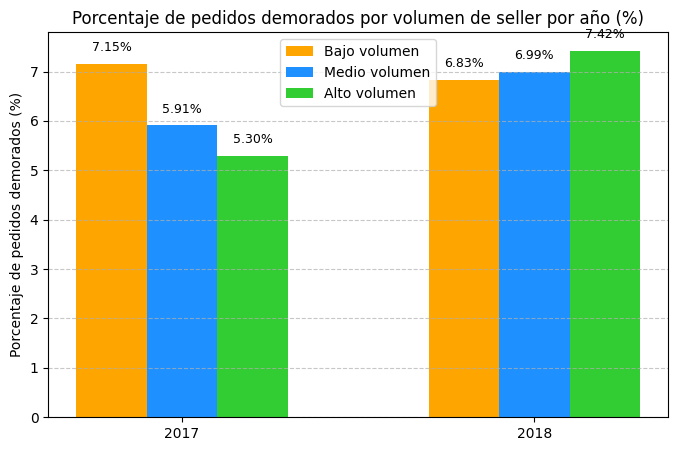

In [190]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos
data = {
    "año": [2017, 2017, 2017, 2018, 2018, 2018],
    "volumen": ["Alto volumen", "Bajo volumen", "Medio volumen",
                "Alto volumen", "Bajo volumen", "Medio volumen"],
    "total_pedidos": [43483, 713, 6668, 50812, 849, 9755],
    "total_demorados": [2303, 51, 394, 3772, 58, 682],
    "porcentaje_demorados": [5.296323, 7.152875, 5.908818, 7.423443, 6.831567, 6.991287]
}

df = pd.DataFrame(data)

# Crear gráfico de barras agrupadas:
fig, ax = plt.subplots(figsize=(8,5))
ancho = 0.2
x = [2017, 2018]

# Filtramos por volumen:
bajo = df[df["volumen"] == "Bajo volumen"]["porcentaje_demorados"].values
medio = df[df["volumen"] == "Medio volumen"]["porcentaje_demorados"].values
alto = df[df["volumen"] == "Alto volumen"]["porcentaje_demorados"].values

# Dibujamos barras con los colores deseados:
bars_bajo = ax.bar([p - ancho for p in x], bajo, width=ancho, label="Bajo volumen", color="#FFA500")   # naranja
bars_medio = ax.bar(x, medio, width=ancho, label="Medio volumen", color="#1E90FF")                    # azul
bars_alto = ax.bar([p + ancho for p in x], alto, width=ancho, label="Alto volumen", color="#32CD32")  # verde

# Añadimos porcentaje encima de cada barra:
for bars in [bars_bajo, bars_medio, bars_alto]:
    for bar in bars:
        altura = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, altura + 0.2, f"{altura:.2f}%", ha="center", va="bottom", fontsize=9)

# Personalizar gráfico
ax.set_xticks(x)
ax.set_xticklabels(x)
ax.set_ylabel("Porcentaje de pedidos demorados (%)")
ax.set_title("Porcentaje de pedidos demorados por volumen de seller por año (%)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


Los sellers de bajo volumen son los que mayor porcentaje de demora tuvieron en ambos años (7.15% en 2017, 6.83% en 2018). Esto indica que los vendedores pequeños tienen menos capacidad logística o experiencia.

Los de medio volumen son los más estables, pues se mantuvieron en un rango intermedio de demora, en torno al 5.91%.

Con respecto a los sellers de alto volumen tuvo el porcentaje de demora más bajo en 2017 (5.30%) pero aumentó notablemente en 2018 hasta el 7.42%. Esto sugiere que el crecimiento del volumen de pedidos afecta principalmente a los vendedores más grandes, posiblemente por saturación logística.

En resumen, todos los sellers mostraron un aumento en el porcentaje de demora, aunque el mayor incremento relativo se dio en el alto volumen, indicando que los picos de demanda impactan más a los vendedores grandes. Los de bajo volumen mejoraron un poco, pero sigue siendo el grupo con mayor riesgo de demora proporcional.

CONCLUSIÓN: 

-Los sellers de alto volumen son más eficientes en general, pues manejan gran cantidad de pedidos con menor porcentaje de retrasos. Sin embargo el incremento de la demanda puede afectar a su rendimiento. 

-Los sellers de bajo volumen siguen siendo los de más riesgo en términos de porcentaje de demora aunque su volumen absoluto es bajo, ya que cada retraso impacta más su desempeño.

-Entre 2017 y 2018, los retrasos de alto volumen aumentaron ligeramente, indicando necesidad de optimizar logística a medida que aumentan los pedidos.

- Evolución de los pedidos demorados por volumen de sellers en 2017 y 2018:

In [ ]:
# Total de pedidos demorados por seller:
demorados_por_seller = df_pedidos.groupby("seller_id").agg(
    total_pedidos=("order_id", "count"),
    total_demorados=("demorados", "sum")
).reset_index()

# Ordenamos por total de pedidos demorados
demorados_por_seller = demorados_por_seller.sort_values(by="total_demorados", ascending=False)


In [ ]:
# % de pedidos demorados de cada seller respecto al total:
total_demorados = demorados_por_seller["total_demorados"].sum()
demorados_por_seller["porcentaje_demorados"] = demorados_por_seller["total_demorados"] / total_demorados * 100

# % acumulado (Pareto):
demorados_por_seller["porcentaje_acumulado"] = demorados_por_seller["porcentaje_demorados"].cumsum()


/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/3526057012.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  total_por_seller_año["volumen"] = total_por_seller_año.groupby("año", group_keys=False).apply(clasificar_volumen)
/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/3526057012.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  volumen_retrasos_año = total_por_seller_año.groupby(["año", "volumen"]).agg(
/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/3526

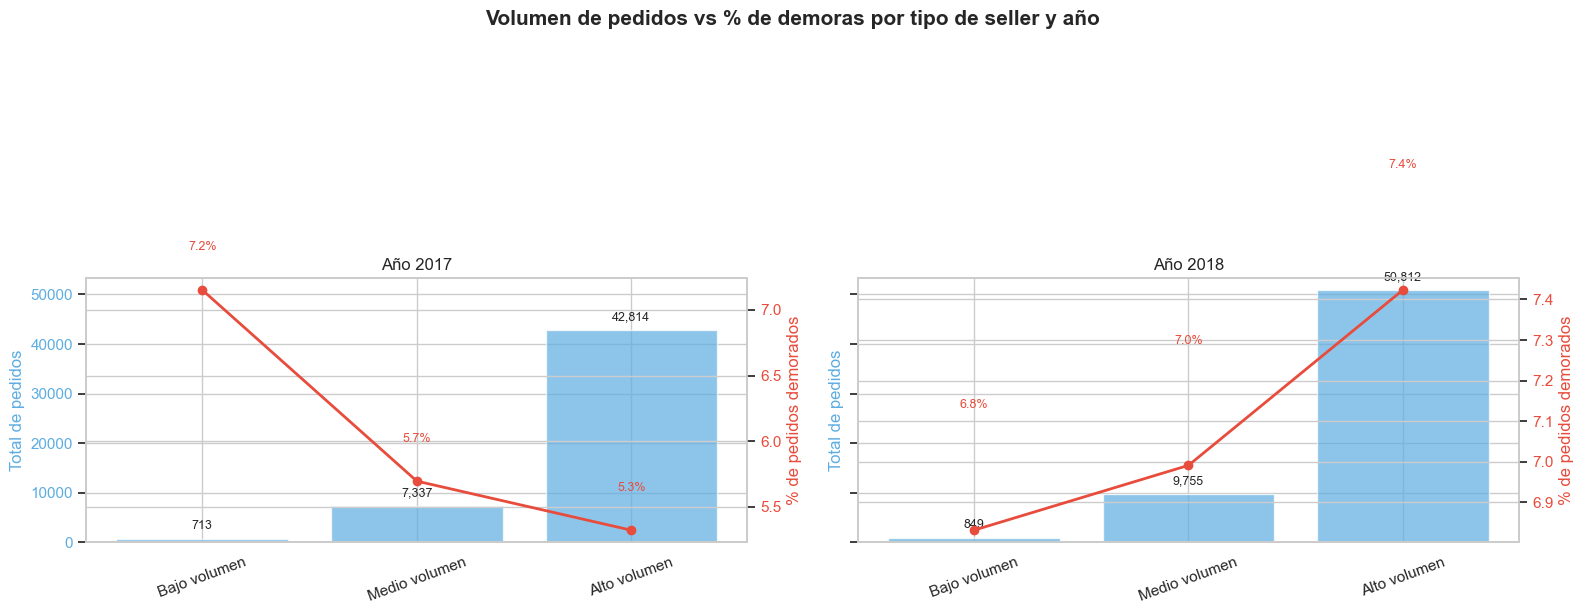

In [193]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#Clasificar sellers por volumen dentro de cada año:
total_por_seller_año = df_pedidos.groupby(["año", "seller_id"]).agg(
    total_pedidos=("order_id", "count"),
    total_demorados=("demorados", "sum")
).reset_index()

# Cuartiles por año:
def clasificar_volumen(df):
    q1 = df["total_pedidos"].quantile(0.25)
    q3 = df["total_pedidos"].quantile(0.75)
    condiciones = [
        (df["total_pedidos"] <= q1),
        (df["total_pedidos"] >= q3)
    ]
    elecciones = ["Bajo volumen", "Alto volumen"]
    return pd.Series(
        pd.cut(df["total_pedidos"], bins=[-1, q1, q3, df["total_pedidos"].max()], 
               labels=["Bajo volumen", "Medio volumen", "Alto volumen"])
    )

total_por_seller_año["volumen"] = total_por_seller_año.groupby("año", group_keys=False).apply(clasificar_volumen)

# Agregar totales por tipo de seller y año:
volumen_retrasos_año = total_por_seller_año.groupby(["año", "volumen"]).agg(
    total_pedidos=("total_pedidos", "sum"),
    total_demorados=("total_demorados", "sum")
).reset_index()

# Calcular porcentaje
volumen_retrasos_año["porcentaje_demorados"] = (
    volumen_retrasos_año["total_demorados"] / volumen_retrasos_año["total_pedidos"] * 100
)

# Filtrar solo años 2017 y 2018:
volumen_retrasos_año_filtrado = volumen_retrasos_año[volumen_retrasos_año["año"].isin([2017, 2018])]


sns.set(style="whitegrid", palette="pastel")

fig, axes = plt.subplots(1, len(volumen_retrasos_año["año"].unique()), figsize=(16,6), sharey=True)

for i, año in enumerate(sorted(volumen_retrasos_año["año"].unique())):
    subset = volumen_retrasos_año[volumen_retrasos_año["año"] == año]
    
    ax1 = axes[i]
    ax1.bar(subset["volumen"], subset["total_pedidos"], color="#5DADE2", alpha=0.7, label="Total pedidos")
    ax1.set_ylabel("Total de pedidos", color="#5DADE2")
    ax1.tick_params(axis="y", labelcolor="#5DADE2")

    # Eje secundario: % demorados
    ax2 = ax1.twinx()
    ax2.plot(subset["volumen"], subset["porcentaje_demorados"], color="#E74C3C", marker="o", linewidth=2, label="% demorados")
    ax2.set_ylabel("% de pedidos demorados", color="#E74C3C")
    ax2.tick_params(axis="y", labelcolor="#E74C3C")

    ax1.set_title(f"Año {año}")
    ax1.set_xlabel("")
    ax1.set_xticklabels(subset["volumen"], rotation=20)
    
    # Añadir etiquetas encima de las barras:
    for j, row in subset.iterrows():
        ax1.text(row["volumen"], row["total_pedidos"] + 2000, f"{int(row['total_pedidos']):,}", 
                 ha="center", fontsize=9)
        ax2.text(row["volumen"], row["porcentaje_demorados"] + 0.3, f"{row['porcentaje_demorados']:.1f}%", 
                 ha="center", fontsize=9, color="#E74C3C")

plt.suptitle("Volumen de pedidos vs % de demoras por tipo de seller y año", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


En los gráficos se puede observar que en 2017 se aprecia un fuerte crecimiento de los sellers de alto volumen llegando a 42.814 pedidos con una tasa de demora inferior a los de bajo y medio volumen. A medida que los grandes sellers crecen, mantienen una tasa de demora relativamente más baja.

En 2018, los sellers de alto volumen siguen concentrando la mayoría de pedidos (50.812), pero su porcentaje de demoras sube a 7.4%, alcanzando a los otros grupos. El crecimiento masivo podría haber reducido su capacidad de mantener eficiencia logística.

Aunque al principio se gestionan mejor las demoras, en 2018 la logística empeora, igualando o superando las tasas de los vendedores pequeños.

En resumen, los grandes sellers concentran la mayoría de pedidos en todos los años, y su peso aumenta progresivamente, a diferencia de los pequeños sellers que se mantienen más estables en el tiempo con un impacto menor por el menor nº de pedidos.


### Categorías más afectadas por sellers demorados según volumen:

In [194]:
# Unimos orders con order_items, sellers y products:
df_pedidos = (
    orders
    .merge(order_items, on="order_id", how="left")
    .merge(sellers, on="seller_id", how="left")
    .merge(products[["product_id", "product_category_name_english"]], on="product_id", how="left")
).copy()

# Aseguramos fechas como datetime:
df_pedidos["order_delivered_customer_date"] = pd.to_datetime(df_pedidos["order_delivered_customer_date"], errors="coerce")
df_pedidos["order_estimated_delivery_date"] = pd.to_datetime(df_pedidos["order_estimated_delivery_date"], errors="coerce")
df_pedidos["order_purchase_timestamp"] = pd.to_datetime(df_pedidos["order_purchase_timestamp"], errors="coerce")

# Creamos variable de demora:
df_pedidos["demorados"] = df_pedidos["order_delivered_customer_date"] > df_pedidos["order_estimated_delivery_date"]

# Extraemos el año:
df_pedidos["año"] = df_pedidos["order_purchase_timestamp"].dt.year




In [204]:
# Calculamos el volumen total por seller y año:
volumen_seller_año = (
    df_pedidos.groupby(["seller_id", "año"])["order_id"]
    .nunique()
    .reset_index()
    .rename(columns={"order_id": "total_pedidos"})
)


In [208]:
# Cuartiles (Q1, Q3):
def clasificar_por_volumen(volumen_seller_año):
    q1 = volumen_seller_año["total_pedidos"].quantile(0.25)
    q3 = volumen_seller_año["total_pedidos"].quantile(0.75)

    # Clasificamos en alto / medio / bajo volumen:
    def asignar_categoria(x):
        if x <= q1:
            return "Bajo volumen"
        elif x >= q3:
            return "Alto volumen"
        else:
            return "Medio volumen"

    volumen_seller_año["tipo_volumen"] = volumen_seller_año["total_pedidos"].apply(asignar_categoria)
    return volumen_seller_año

# Aplicamos por año:
volumen_seller_año = volumen_seller_año.groupby("año", group_keys=False).apply(clasificar_por_volumen)




/var/folders/4q/q0lqp61n59n78l0zk3_r92d00000gn/T/ipykernel_54800/51533732.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  volumen_seller_año = volumen_seller_año.groupby("año", group_keys=False).apply(clasificar_por_volumen)


In [209]:
# Agrupamos "volumen_seller_año" a df_pedidos:
df_pedidos = df_pedidos.merge(volumen_seller_año[["seller_id", "año", "tipo_volumen"]], on=["seller_id", "año"], how="left")

In [210]:
# Agrupamos por año, categoría y tipo de volumen
categorias_demoradas = (
    df_pedidos.groupby(["año", "product_category_name_english", "tipo_volumen"])
    .agg(
        total_pedidos=("order_id", "count"),
        total_demorados=("demorados", "sum")
    )
    .reset_index()
)

# Calculamos el porcentaje de pedidos demorados
categorias_demoradas["porcentaje_demorados"] = (
    categorias_demoradas["total_demorados"] / categorias_demoradas["total_pedidos"] * 100
)


In [212]:
categorias_demoradas.sort_values(by=["año","porcentaje_demorados"], ascending=[False,False]).reset_index().head(10)

,index,año,product_category_name_english,tipo_volumen,total_pedidos,total_demorados,porcentaje_demorados
0,278,2018,computers,Medio volumen,1,1,100.000000
1,268,2018,books_technical,Bajo volumen,4,2,50.000000
2,277,2018,computers,Bajo volumen,2,1,50.000000
3,389,2018,office_furniture,Bajo volumen,2,1,50.000000
4,283,2018,consoles_games,Bajo volumen,6,2,33.333333
5,358,2018,home_appliances_2,Bajo volumen,3,1,33.333333
6,360,2018,home_comfort_2,Alto volumen,9,3,33.333333
7,325,2018,fashion_underwear_beach,Medio volumen,7,2,28.571429
8,289,2018,construction_tools_lights,Bajo volumen,27,7,25.925926
9,248,2018,arts_and_craftmanship,Alto volumen,8,2,25.000000


In [217]:
# Top 10 categorías más afectadas por año y volumen:
categorias_demoradas = categorias_demoradas[categorias_demoradas["año"].isin([2017, 2018])]

top_categorias = (
    categorias_demoradas.sort_values(by=["año", "porcentaje_demorados"], ascending=[False, False])
    .groupby("año")
    .head(10)
)

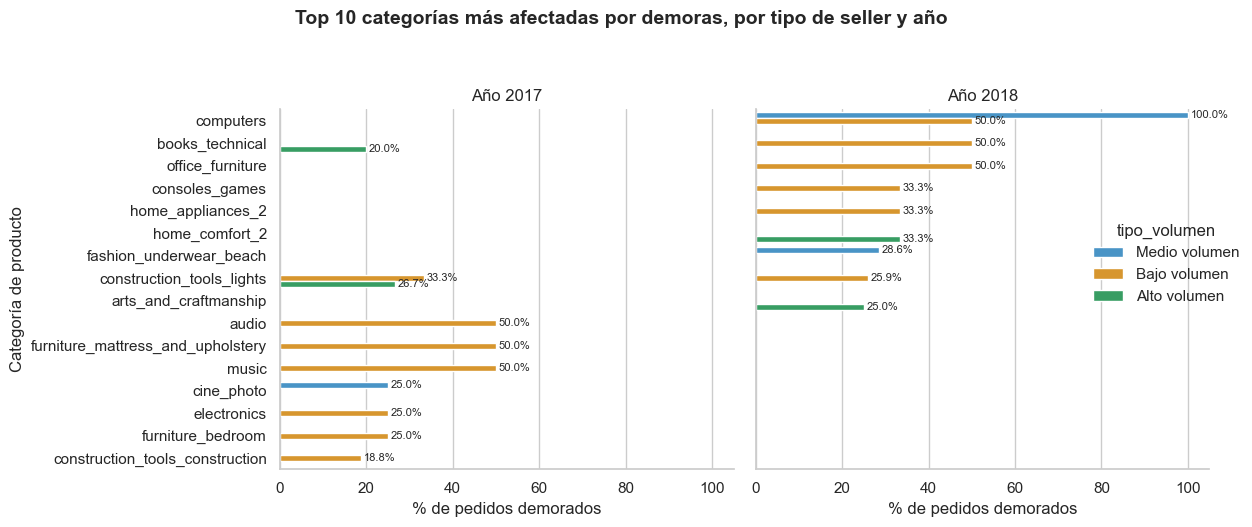

In [219]:
import seaborn as sns
import matplotlib.pyplot as plt

top_categorias["product_category_name_english"] = top_categorias.groupby("año")["product_category_name_english"].transform(
    lambda x: pd.Categorical(x, categories=x.unique()[::-1], ordered=True)
)

# Paleta personalizada
palette = {
    "Bajo volumen": "#F39C12",   # naranja
    "Medio volumen": "#3498DB",  # azul
    "Alto volumen": "#27AE60"    # verde
}

# Crear el gráfico
sns.set(style="whitegrid", font_scale=1.0)
g = sns.catplot(
    data=top_categorias,
    x="porcentaje_demorados",
    y="product_category_name_english",
    hue="tipo_volumen",
    col="año",
    kind="bar",
    height=5,
    aspect=1.1,
    palette=palette
)

# Ajustes visuales
g.set_titles("Año {col_name}")
g.set_axis_labels("% de pedidos demorados", "Categoría de producto")
g.fig.suptitle("Top 10 categorías más afectadas por demoras, por tipo de seller y año", fontsize=14, fontweight="bold", y=1.05)

# Añadir etiquetas de porcentaje en las barras
for ax in g.axes.flat:
    for c in ax.containers:
        ax.bar_label(c, fmt="%.1f%%", fontsize=8, label_type="edge", padding=2)

plt.tight_layout()
plt.show()


En el gráfico se ve que en 2017 predominan los sellers de bajo volumen entre las categorías con más demoras. Esto sugiere que estos sellers presentan más dificultades logísticas o de gestión de stock. Las categorías con mayor incidencia de demoras fueron audio, furniture_mattress_and_upholstery y music, todas con 50% de pedidos demorados. Hubo categorías como muebles o equipos electrónicos que tienden a tener más retrasos, posiblemente por procesos de envío más complejos.

En 2018 se ve que las categorías más afectadas son computers y Books_technical, y también office_furniture y home_comfort_2 con más de 30% demorados, reflejando dificultades en transporte de bienes voluminosos.

Hay un aumento generalizado en los porcentajes de demora, alcanzando incluso 100% en “computers”. En este año, los sellers de bajo volumen concentran también la mayoría de las demoras, aunque también hay sellers de alto volumen con ~25–33% de pedidos demorados debido a un crecimiento de demanda que superó su capacidad logística. 

### Evolución del tiempo de entrega y estado de pedidos (2017–2018):

In [242]:
orders_entregados["order_purchase_timestamp"]= pd.to_datetime(orders_entregados["order_purchase_timestamp"])

#Extraemos año de la compra:

orders_entregados["año"] = orders_entregados["order_purchase_timestamp"].dt.year

#Filtramos solo años 2017 y 2018:
orders_entregados = orders_entregados[orders_entregados["año"].isin([2017, 2018])]

In [243]:
promedio_entrega_año= orders_entregados.groupby("año")["días_entrega"].mean().reset_index()
promedio_entrega_año.rename(columns={"días_entrega" : "promedio_anual_entrega"}, inplace=True)
promedio_entrega_año

,año,promedio_anual_entrega
0,2017,12.541335
1,2018,11.689202


In [246]:
# Promedio de días de entrega por año:
promedio_entrega_año = score_demorados[score_demorados["año"] != 2016].groupby("año")["días_entrega"].mean().reset_index()
promedio_entrega_año.rename(columns={"días_entrega": "promedio_anual_entrega"}, inplace=True)

# Distribución de status por año:
status_por_año = (
    df_pedidos.groupby(["año", "order_status"])["order_id"]
    .count()
    .reset_index()
    .rename(columns={"order_id": "num_pedidos"})
)

# Calculamos el total de pedidos por año para sacar porcentaje:
total_por_año = (
    df_pedidos.groupby("año")["order_id"].count().reset_index().rename(columns={"order_id": "total_pedidos"})
)

status_por_año = status_por_año.merge(total_por_año, on="año", how="left")
status_por_año["porcentaje"] = (status_por_año["num_pedidos"] / status_por_año["total_pedidos"]) * 100

# Unimos todo en un solo df:
entrega_status = promedio_entrega_año.merge(
    status_por_año[status_por_año["order_status"].isin(["delivered", "canceled"])],
    on="año",
    how="left"
)

entrega_status


,año,promedio_anual_entrega,order_status,num_pedidos,total_pedidos,porcentaje
0,2017,36.224223,canceled,308,51386,0.599385
1,2017,36.224223,delivered,49556,51386,96.438719
2,2018,31.743413,canceled,370,61652,0.600143
3,2018,31.743413,delivered,60324,61652,97.845974


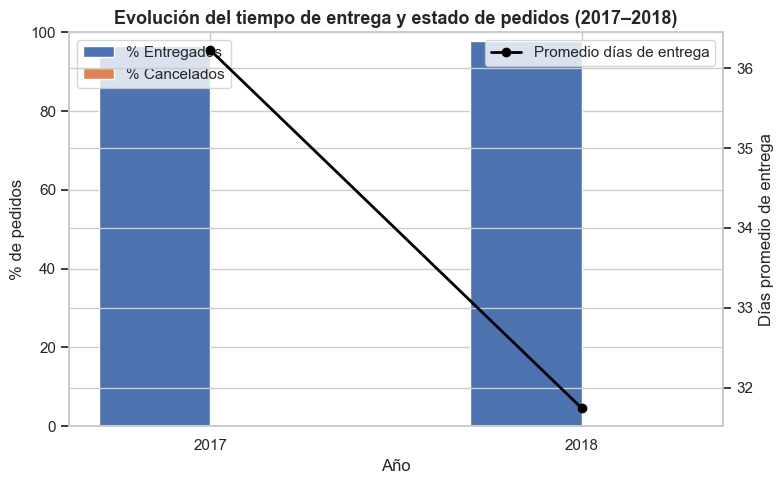

In [247]:
import matplotlib.pyplot as plt


# Pivot: columnas = estados (delivered / canceled)
pivot = (
    entrega_status
    .pivot(index="año", columns="order_status", values="porcentaje")
    .reset_index()
)

# Añadimos el promedio anual de entrega
promedios = (
    entrega_status[["año", "promedio_anual_entrega"]]
    .drop_duplicates("año")
    .set_index("año")
)
pivot["promedio_anual_entrega"] = pivot["año"].map(promedios["promedio_anual_entrega"])

# Gráfico combinado:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Barras por año
x = range(len(pivot["año"]))
ax1.bar([i - 0.15 for i in x], pivot["delivered"], width=0.3, label="% Entregados")
ax1.bar([i + 0.15 for i in x], pivot["canceled"], width=0.3, label="% Cancelados")

ax1.set_ylabel("% de pedidos")
ax1.set_ylim(0, 100)
ax1.set_xlabel("Año")
ax1.set_xticks(x)
ax1.set_xticklabels(pivot["año"].astype(int)) 

# Línea del promedio anual de entrega:
ax2 = ax1.twinx()
ax2.plot(x, pivot["promedio_anual_entrega"], color="black", marker="o", linewidth=2, label="Promedio días de entrega")
ax2.set_ylabel("Días promedio de entrega")

plt.title("Evolución del tiempo de entrega y estado de pedidos (2017–2018)", fontsize=13, fontweight="bold")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()



Existe una reducción del tiempo de entrega, pasando de 36,2 días en 2017 a 31,7 días en 2018, lo que supone una mejora de cerca del 12% en los tiempos de entrega. Esto indica un proceso logístico más eficiente o una mejor planificación del fulfillment.

En ambos años, los pedidos entregados superan el 96% del total, lo que refleja una operativa estable y efectiva, y el porcentaje de cancelaciones se mantiene muy bajo (0,6%).

Entre 2017 y 2018 se observa una mejora significativa en la eficiencia logística: el tiempo promedio de entrega disminuye de 36 a 31 días, mientras que el volumen de pedidos crece más de 61.000 pedidos frente a 51.000 en 2017. 

A pesar del aumento del volumen de pedidos, las cancelaciones permanecen estables y mínimas (≈0,6%), lo que sugiere una optimización en los procesos de entrega y gestión operativa durante 2018.

En resumen, se observa una mejora significativa en la eficiencia logística entre 2017 y 2018: el tiempo promedio de entrega disminuye de 36 a 31 días, mientras que el porcentaje de pedidos entregados se mantiene por encima del 96%.
